# Section 3 — Recommendation Classifier

This notebook compares two models on the same leakage-free splits:

1. **TF-IDF + Logistic Regression**
2. **Frozen ParsBERT embeddings + Logistic Regression**

ParsBERT is **not fine-tuned**.

```text
comments_clean_v1.parquet
        ↓
shared Persian normalizer
        ↓
group split by product_id
        ↓
moderate fixed samples
        ├── TF-IDF → Logistic Regression
        └── Frozen ParsBERT → fixed embeddings → Logistic Regression
```

The exact splits, models, embeddings, predictions, and evaluation outputs are persisted on Google Drive.

## 1. Mount Google Drive

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Runtime dependencies

The notebook checks the packages required for Parquet loading, evaluation, and frozen ParsBERT feature extraction.

In [5]:
import importlib.util
import subprocess
import sys

def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", pip_name or import_name]
        )

ensure_package("pyarrow")
ensure_package("joblib")
ensure_package("sklearn", "scikit-learn")
ensure_package("transformers")

print("Required runtime dependencies are available.")

Required runtime dependencies are available.


## 2. Configuration

In [6]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/DigikalaProject")
DATA_PATH = PROJECT_ROOT / "processed" / "comments_clean_v1.parquet"

RUN_ROOT = PROJECT_ROOT / "models" / "recommendation_classifier_v2"
SPLIT_DIR = RUN_ROOT / "splits"
EMBED_DIR = RUN_ROOT / "parsbert_embeddings"
MODEL_DIR = RUN_ROOT / "models"
EVAL_DIR = PROJECT_ROOT / "eval" / "fatemeh" / "recommendation_classifier_v2"

for p in [RUN_ROOT, SPLIT_DIR, EMBED_DIR, MODEL_DIR, EVAL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 42
TRAIN_N = 60_000
VAL_N = 15_000
TEST_N = 20_000

MODEL_NAME = "HooshvareLab/bert-base-parsbert-uncased"
MAX_LENGTH = 128
EMBED_BATCH_SIZE = 64
EMBED_SHARD_SIZE = 5_000

print(DATA_PATH)

/content/drive/MyDrive/DigikalaProject/processed/comments_clean_v1.parquet


## 3. Imports

In [7]:
import gc, hashlib, json, os, random, re, unicodedata
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoModel, AutoTokenizer
from tqdm.auto import tqdm

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA: True
Tesla T4


## 4. Shared Persian normalizer

Adapted from Ali's shared `src/data/normalize.py`.

In [8]:
# Shared normalizer snapshot — Owner: Ali

ZWNJ = "\u200c"

_CHAR_MAP = {
    "ي":"ی","ى":"ی","ك":"ک","أ":"ا","إ":"ا","ٱ":"ا",
    "ة":"ه","ۀ":"ه","ؤ":"و","٫":".","٬":",","،":",",
    "؛":";","؟":"?","٪":"%","«":'"',"»":'"',
}
for _i, (_fa, _ar) in enumerate(zip("۰۱۲۳۴۵۶۷۸۹","٠١٢٣٤٥٦٧٨٩")):
    _CHAR_MAP[_fa] = str(_i)
    _CHAR_MAP[_ar] = str(_i)

_DROP_CHARS = "".join(chr(c) for c in [
    *range(0x064B,0x0653),0x0654,0x0655,0x0670,0x0640,
    0x200B,0x200D,0x200E,0x200F,0x202A,0x202B,0x202C,
    0x202D,0x202E,0x2066,0x2067,0x2068,0x2069,0xFEFF
])
_SPACE_CHARS = "".join(chr(c) for c in [
    0x00A0,*range(0x2000,0x200B),0x202F,0x205F,0x3000
])

_TRANSLATE = {ord(k):v for k,v in _CHAR_MAP.items()}
_TRANSLATE.update({ord(c):None for c in _DROP_CHARS})
_TRANSLATE.update({ord(c):" " for c in _SPACE_CHARS})

_EMOJI_RE = re.compile(
    "[" "\U0001f000-\U0001faff" "\u2190-\u21ff" "\u2600-\u27bf"
    "\u2b00-\u2bff" "\ufe00-\ufe0f" "\u2049\u203c\u2122" "]+"
)
_REPEAT_FA_RE = re.compile(r"([\u0600-\u06ff])\1{2,}")
_REPEAT_LATIN_RE = re.compile(r"([A-Za-z])\1{2,}")
_SPACE_RE = re.compile(r"\s+")
_ZWNJ_RE = re.compile(r"[ ]*\u200c[ \u200c]*")

def normalize(text):
    if not isinstance(text, str):
        return ""
    s = unicodedata.normalize("NFKC", text)
    s = s.translate(_TRANSLATE)
    s = _EMOJI_RE.sub(" ", s)
    s = _REPEAT_FA_RE.sub(r"\1", s)
    s = _REPEAT_LATIN_RE.sub(r"\1\1", s)
    s = _SPACE_RE.sub(" ", s)
    s = _ZWNJ_RE.sub(ZWNJ, s)
    return s.strip().strip(ZWNJ).strip()

## 5. Resolve schema and load data

In [9]:
import pyarrow.parquet as pq

available = pq.ParquetFile(DATA_PATH).schema.names
print(available)

def pick(options):
    return next((x for x in options if x in available), None)

TEXT_COL = pick(["text","body"])
LABEL_COL = pick(["recommendation_status","status_recommendation"])
PRODUCT_COL = pick(["product_id","id_product"])
COMMENT_COL = pick(["comment_id","id"])

if None in [TEXT_COL, LABEL_COL, PRODUCT_COL]:
    raise ValueError((TEXT_COL, LABEL_COL, PRODUCT_COL))

cols = [TEXT_COL, LABEL_COL, PRODUCT_COL]
if COMMENT_COL and COMMENT_COL not in cols:
    cols.append(COMMENT_COL)

df = pd.read_parquet(DATA_PATH, columns=cols)

rename_map = {
    TEXT_COL:"text",
    LABEL_COL:"recommendation_status",
    PRODUCT_COL:"product_id",
}
if COMMENT_COL:
    rename_map[COMMENT_COL] = "comment_id"

df = df.rename(columns=rename_map)

VALID_LABELS = {"recommended","not_recommended","no_idea"}

df = df[
    df["text"].notna()
    & df["product_id"].notna()
    & df["recommendation_status"].notna()
].copy()

df["text"] = df["text"].astype(str)
df["recommendation_status"] = df["recommendation_status"].astype(str).str.strip()

df = df[
    df["recommendation_status"].isin(VALID_LABELS)
    & df["text"].str.strip().ne("")
].reset_index(drop=True)

print("Rows:", len(df))
print("Products:", df["product_id"].nunique())
display(df["recommendation_status"].value_counts())

['comment_id', 'product_id', 'title', 'body', 'advantages', 'disadvantages', 'rate', 'recommendation_status', 'is_buyer', 'likes', 'dislikes', 'created_at', 'search_text']
Rows: 4704349
Products: 300043


,count
recommendation_status,
recommended,3667777
no_idea,549323
not_recommended,487249


## 6. Leakage-free group split and moderate sampling

The full dataset is split by `product_id` before sampling.

In [10]:
TRAIN_PATH = SPLIT_DIR / "train_60000.parquet"
VAL_PATH = SPLIT_DIR / "val_15000.parquet"
TEST_PATH = SPLIT_DIR / "test_20000.parquet"
SPLIT_MANIFEST_PATH = SPLIT_DIR / "split_manifest.json"

def stratified_sample(frame, n, seed):
    if len(frame) <= n:
        return frame.sample(frac=1, random_state=seed).reset_index(drop=True)

    sample, _ = train_test_split(
        frame,
        train_size=n,
        stratify=frame["recommendation_status"],
        random_state=seed,
    )
    return sample.reset_index(drop=True)

def normalize_split(frame):
    frame = frame.copy()
    frame["text"] = frame["text"].map(normalize)
    frame = frame[frame["text"].ne("")].reset_index(drop=True)
    return frame

def split_fingerprint(frame):
    cols = ["product_id", "recommendation_status", "text"]
    hashed = pd.util.hash_pandas_object(
        frame[cols],
        index=False,
    ).values
    return hashlib.sha256(hashed.tobytes()).hexdigest()

cached_splits = all(
    p.exists() for p in [TRAIN_PATH, VAL_PATH, TEST_PATH, SPLIT_MANIFEST_PATH]
)

if cached_splits:
    train_df = normalize_split(pd.read_parquet(TRAIN_PATH))
    val_df = normalize_split(pd.read_parquet(VAL_PATH))
    test_df = normalize_split(pd.read_parquet(TEST_PATH))
    print("Loaded cached splits from Drive.")

else:
    g1 = GroupShuffleSplit(
        n_splits=1,
        test_size=0.15,
        random_state=SEED,
    )

    trainval_idx, test_idx = next(
        g1.split(df, groups=df["product_id"])
    )

    trainval = df.iloc[trainval_idx].reset_index(drop=True)
    test_pool = df.iloc[test_idx].reset_index(drop=True)

    g2 = GroupShuffleSplit(
        n_splits=1,
        test_size=0.15 / 0.85,
        random_state=SEED + 1,
    )

    train_idx, val_idx = next(
        g2.split(
            trainval,
            groups=trainval["product_id"],
        )
    )

    train_pool = trainval.iloc[train_idx].reset_index(drop=True)
    val_pool = trainval.iloc[val_idx].reset_index(drop=True)

    train_df = normalize_split(
        stratified_sample(train_pool, TRAIN_N, SEED)
    )
    val_df = normalize_split(
        stratified_sample(val_pool, VAL_N, SEED + 1)
    )
    test_df = normalize_split(
        stratified_sample(test_pool, TEST_N, SEED + 2)
    )

    for name, part in [
        ("train", train_df),
        ("val", val_df),
        ("test", test_df),
    ]:
        missing_labels = VALID_LABELS - set(part["recommendation_status"].unique())
        if missing_labels:
            raise RuntimeError(
                f"{name} split is missing labels: {sorted(missing_labels)}"
            )

    train_df.to_parquet(TRAIN_PATH, index=False)
    val_df.to_parquet(VAL_PATH, index=False)
    test_df.to_parquet(TEST_PATH, index=False)

    manifest = {
        "source_data": str(DATA_PATH),
        "seed": SEED,
        "split_strategy": "GroupShuffleSplit by product_id before stratified row sampling",
        "train_rows": len(train_df),
        "val_rows": len(val_df),
        "test_rows": len(test_df),
        "train_fingerprint": split_fingerprint(train_df),
        "val_fingerprint": split_fingerprint(val_df),
        "test_fingerprint": split_fingerprint(test_df),
        "normalizer": "shared src/data/normalize.py snapshot",
    }

    SPLIT_MANIFEST_PATH.write_text(
        json.dumps(manifest, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    print("Saved fixed leakage-free splits to Drive.")

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

Loaded cached splits from Drive.
Train: (60000, 4)
Val:   (15000, 4)
Test:  (20000, 4)


## 7. Leakage check

In [11]:
tp = set(train_df["product_id"])
vp = set(val_df["product_id"])
sp = set(test_df["product_id"])

assert tp.isdisjoint(vp)
assert tp.isdisjoint(sp)
assert vp.isdisjoint(sp)

print("No product leakage.")

No product leakage.


In [12]:
split_manifest = json.loads(
    SPLIT_MANIFEST_PATH.read_text(encoding="utf-8")
)

current_fingerprints = {
    "train_fingerprint": split_fingerprint(train_df),
    "val_fingerprint": split_fingerprint(val_df),
    "test_fingerprint": split_fingerprint(test_df),
}

for key, value in current_fingerprints.items():
    if split_manifest.get(key) != value:
        raise RuntimeError(
            f"Cached split fingerprint mismatch for {key}. "
            "Delete recommendation_classifier_v2/splits and rebuild once."
        )

print("Split fingerprints verified.")

Split fingerprints verified.


## 8. Label encoding

In [13]:
le = LabelEncoder()
le.fit(sorted(VALID_LABELS))
LABELS = le.classes_.tolist()

y_train = le.transform(train_df["recommendation_status"])
y_val = le.transform(val_df["recommendation_status"])
y_test = le.transform(test_df["recommendation_status"])

(MODEL_DIR / "label_classes.json").write_text(
    json.dumps(LABELS, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print(LABELS)

['no_idea', 'not_recommended', 'recommended']


# Model A — TF-IDF + Logistic Regression

In [14]:
TFIDF_PATH = MODEL_DIR / "tfidf_logreg.joblib"

if TFIDF_PATH.exists():
    bundle = joblib.load(TFIDF_PATH)

    if bundle.get("train_fingerprint") != current_fingerprints["train_fingerprint"]:
        raise RuntimeError(
            "Saved TF-IDF model belongs to a different training split."
        )

    tfidf = bundle["vectorizer"]
    tfidf_model = bundle["model"]

else:
    tfidf = TfidfVectorizer(
        max_features=80_000,
        ngram_range=(1, 2),
        min_df=3,
        sublinear_tf=True,
        dtype=np.float32,
    )

    Xtr = tfidf.fit_transform(train_df["text"])

    tfidf_model = LogisticRegression(
        max_iter=300,
        class_weight="balanced",
        solver="saga",
        n_jobs=-1,
        random_state=SEED,
    )

    tfidf_model.fit(Xtr, y_train)

    joblib.dump(
        {
            "vectorizer": tfidf,
            "model": tfidf_model,
            "train_fingerprint": current_fingerprints["train_fingerprint"],
        },
        TFIDF_PATH,
    )

    del Xtr
    gc.collect()

def eval_text(model, vectorizer, frame, y):
    pred = model.predict(
        vectorizer.transform(frame["text"])
    )
    return f1_score(
        y,
        pred,
        average="macro",
    ), pred

tfidf_val_f1, tfidf_val_pred = eval_text(
    tfidf_model,
    tfidf,
    val_df,
    y_val,
)

tfidf_test_f1, tfidf_test_pred = eval_text(
    tfidf_model,
    tfidf,
    test_df,
    y_test,
)

print("TF-IDF val Macro F1:", round(tfidf_val_f1, 4))
print("TF-IDF test Macro F1:", round(tfidf_test_f1, 4))

TF-IDF val Macro F1: 0.65
TF-IDF test Macro F1: 0.6543


## Validation Error Analysis — TF-IDF Baseline

The validation split is used to inspect the dominant classification errors before selecting the next model. The test split is not used for model selection.

In [15]:
val_errors = val_df.copy()

val_errors["true_label"] = le.inverse_transform(y_val)
val_errors["tfidf_prediction"] = le.inverse_transform(tfidf_val_pred)
val_errors["correct"] = (
    val_errors["true_label"] == val_errors["tfidf_prediction"]
)

error_pairs = (
    val_errors.loc[~val_errors["correct"]]
    .groupby(["true_label", "tfidf_prediction"])
    .size()
    .sort_values(ascending=False)
)

print("Validation errors:", (~val_errors["correct"]).sum())
display(error_pairs.to_frame("count"))

Validation errors: 3045


,,count
true_label,tfidf_prediction,
recommended,no_idea,1464
no_idea,recommended,566
not_recommended,no_idea,462
no_idea,not_recommended,205
not_recommended,recommended,174
recommended,not_recommended,174


## Model A2 — Word + Character TF-IDF with LinearSVC

Character n-grams are added to the word-level TF-IDF representation to better capture spelling variation, informal Persian, suffixes, and short sentiment expressions.

Hyperparameters are selected using Validation Macro F1 only.

In [16]:
from sklearn.pipeline import FeatureUnion
from sklearn.svm import LinearSVC

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    max_features=70_000,
    min_df=2,
    sublinear_tf=True,
    dtype=np.float32,
)

char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=90_000,
    min_df=2,
    sublinear_tf=True,
    dtype=np.float32,
)

word_char_vectorizer = FeatureUnion(
    [
        ("word", word_vectorizer),
        ("char", char_vectorizer),
    ],
    n_jobs=1,  # lower memory usage on Colab
)

print("Building Word + Character TF-IDF features...")

X_train_wc = word_char_vectorizer.fit_transform(train_df["text"])
X_val_wc = word_char_vectorizer.transform(val_df["text"])

print("Train shape:", X_train_wc.shape)
print("Validation shape:", X_val_wc.shape)

Building Word + Character TF-IDF features...
Train shape: (60000, 131874)
Validation shape: (15000, 131874)


In [17]:
no_idea_id = int(le.transform(["no_idea"])[0])
not_recommended_id = int(le.transform(["not_recommended"])[0])
recommended_id = int(le.transform(["recommended"])[0])

mild_class_weights = {
    no_idea_id: 1.3,
    not_recommended_id: 1.6,
    recommended_id: 1.0,
}

svc_configs = [
    ("unweighted_C0.5", 0.5, None),
    ("unweighted_C1.0", 1.0, None),

    ("balanced_C0.5", 0.5, "balanced"),
    ("balanced_C1.0", 1.0, "balanced"),

    ("mild_weights_C0.5", 0.5, mild_class_weights),
    ("mild_weights_C1.0", 1.0, mild_class_weights),
]

svc_results = []
best_svc = None
best_svc_name = None
best_svc_val_pred = None
best_svc_val_f1 = -1.0

for name, C, class_weight in svc_configs:

    model = LinearSVC(
        C=C,
        class_weight=class_weight,
        max_iter=5000,
        random_state=SEED,
    )

    model.fit(X_train_wc, y_train)

    val_pred = model.predict(X_val_wc)

    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
    )

    svc_results.append(
        {
            "config": name,
            "C": C,
            "validation_macro_f1": val_f1,
        }
    )

    print(f"{name}: {val_f1:.4f}")

    if val_f1 > best_svc_val_f1:
        best_svc_val_f1 = val_f1
        best_svc = model
        best_svc_name = name
        best_svc_val_pred = val_pred.copy()

svc_results_df = (
    pd.DataFrame(svc_results)
    .sort_values("validation_macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("\nBest configuration:", best_svc_name)
print("Best Validation Macro F1:", round(best_svc_val_f1, 4))

display(svc_results_df)

unweighted_C0.5: 0.6340
unweighted_C1.0: 0.6354
balanced_C0.5: 0.6526
balanced_C1.0: 0.6406
mild_weights_C0.5: 0.6408
mild_weights_C1.0: 0.6373

Best configuration: balanced_C0.5
Best Validation Macro F1: 0.6526


,config,C,validation_macro_f1
0,balanced_C0.5,0.5,0.652572
1,mild_weights_C0.5,0.5,0.640835
2,balanced_C1.0,1.0,0.640642
3,mild_weights_C1.0,1.0,0.637341
4,unweighted_C1.0,1.0,0.635379
5,unweighted_C0.5,0.5,0.633958


In [18]:
print(
    classification_report(
        y_val,
        best_svc_val_pred,
        target_names=LABELS,
        digits=4,
    )
)

svc_cm = confusion_matrix(
    y_val,
    best_svc_val_pred,
    labels=np.arange(len(LABELS)),
)

display(
    pd.DataFrame(
        svc_cm,
        index=[f"true_{x}" for x in LABELS],
        columns=[f"pred_{x}" for x in LABELS],
    )
)

SVC_MODEL_PATH = MODEL_DIR / "tfidf_word_char_linearsvc.joblib"

joblib.dump(
    {
        "vectorizer": word_char_vectorizer,
        "model": best_svc,
        "validation_macro_f1": best_svc_val_f1,
        "best_config": best_svc_name,
        "train_fingerprint": current_fingerprints["train_fingerprint"],
    },
    SVC_MODEL_PATH,
)

print("Saved:", SVC_MODEL_PATH)

                 precision    recall  f1-score   support

        no_idea     0.3935    0.3821    0.3877      1730
not_recommended     0.6457    0.6617    0.6536      1537
    recommended     0.9160    0.9169    0.9164     11733

       accuracy                         0.8291     15000
      macro avg     0.6517    0.6536    0.6526     15000
   weighted avg     0.8280    0.8291    0.8285     15000



,pred_no_idea,pred_not_recommended,pred_recommended
true_no_idea,661,295,774
true_not_recommended,307,1017,213
true_recommended,712,263,10758


Saved: /content/drive/MyDrive/DigikalaProject/models/recommendation_classifier_v2/models/tfidf_word_char_linearsvc.joblib


## Model A3 — Rich Review Text + Word/Character TF-IDF + LinearSVC

The previous classifiers used only the review body.

This experiment enriches the input with other textual fields from the same review:
title, body, advantages, and disadvantages.

The original leakage-free product-level splits are preserved. Additional fields are joined only by comment_id.
Model selection is based only on Validation Macro F1.

In [23]:
import pyarrow.parquet as pq
import pandas as pd

RICH_AUX_PATH = SPLIT_DIR / "richtext_aux_train_val.parquet"

if "comment_id" not in train_df.columns or "comment_id" not in val_df.columns:
    raise RuntimeError(
        "comment_id is required to attach the additional review text fields."
    )

train_ids = train_df["comment_id"].astype(str)
val_ids = val_df["comment_id"].astype(str)

target_ids = set(train_ids) | set(val_ids)

print("Target comments:", len(target_ids))

if RICH_AUX_PATH.exists():

    rich_aux = pd.read_parquet(RICH_AUX_PATH)

    print("Loaded cached rich-text fields from Drive.")

else:

    parquet_file = pq.ParquetFile(DATA_PATH)

    matched_parts = []

    for batch in parquet_file.iter_batches(
        columns=[
            "comment_id",
            "title",
            "advantages",
            "disadvantages",
        ],
        batch_size=200_000,
    ):

        part = batch.to_pandas()

        part["comment_id"] = part["comment_id"].astype(str)

        part = part[
            part["comment_id"].isin(target_ids)
        ]

        if not part.empty:
            matched_parts.append(part)

    rich_aux = pd.concat(
        matched_parts,
        ignore_index=True,
    )

    if rich_aux["comment_id"].duplicated().any():
        duplicate_count = int(
            rich_aux["comment_id"].duplicated().sum()
        )
        raise RuntimeError(
            f"Duplicate comment_id values found: {duplicate_count}"
        )

    found_ids = set(rich_aux["comment_id"])

    missing_ids = target_ids - found_ids

    if missing_ids:
        raise RuntimeError(
            f"{len(missing_ids)} split comments were not found in the source parquet."
        )

    rich_aux.to_parquet(
        RICH_AUX_PATH,
        index=False,
    )

    print("Saved rich-text fields:", RICH_AUX_PATH)

print("Matched rows:", len(rich_aux))
display(rich_aux.head())

Target comments: 75000
Saved rich-text fields: /content/drive/MyDrive/DigikalaProject/models/recommendation_classifier_v2/splits/richtext_aux_train_val.parquet
Matched rows: 75000


,comment_id,title,advantages,disadvantages
0,27196727,None,"جنس خوب, شکلای قشنگ, قسمت مناسب",ندارد
1,47152840,پدفرمژه,None,None
2,32299528,None,None,None
3,18546310,None,None,None
4,47606851,به اندازه ی یه بند انگشت از این محصول داخل رنگ...,None,None


In [24]:
def attach_rich_text(frame, aux):

    result = frame.copy()

    result["comment_id"] = result["comment_id"].astype(str)

    result = result.merge(
        aux,
        on="comment_id",
        how="left",
        validate="one_to_one",
        sort=False,
    )

    title = (
        result["title"]
        .fillna("")
        .astype(str)
        .map(normalize)
    )

    advantages = (
        result["advantages"]
        .fillna("")
        .astype(str)
        .map(normalize)
    )

    disadvantages = (
        result["disadvantages"]
        .fillna("")
        .astype(str)
        .map(normalize)
    )

    body = (
        result["text"]
        .fillna("")
        .astype(str)
    )

    result["rich_text"] = (
        "عنوان: " + title
        + " | متن: " + body
        + " | نکات مثبت: " + advantages
        + " | نکات منفی: " + disadvantages
    ).map(normalize)

    return result


train_rich = attach_rich_text(
    train_df,
    rich_aux,
)

val_rich = attach_rich_text(
    val_df,
    rich_aux,
)

assert len(train_rich) == len(train_df)
assert len(val_rich) == len(val_df)

assert (
    train_rich["recommendation_status"].to_numpy()
    == train_df["recommendation_status"].to_numpy()
).all()

assert (
    val_rich["recommendation_status"].to_numpy()
    == val_df["recommendation_status"].to_numpy()
).all()

print("Train:", train_rich.shape)
print("Validation:", val_rich.shape)

display(
    train_rich[
        [
            "text",
            "title",
            "advantages",
            "disadvantages",
            "rich_text",
        ]
    ].head(10)
)

Train: (60000, 8)
Validation: (15000, 8)


,text,title,advantages,disadvantages,rich_text
0,کتاب فوق العادیه,None,None,None,عنوان: | متن: کتاب فوق العادیه | نکات مثبت: | ...
1,وزن کم کیفیت پایین,None,None,None,عنوان: | متن: وزن کم کیفیت پایین | نکات مثبت: ...
2,خوب و زیبا هست,عالی,None,None,عنوان: عالی | متن: خوب و زیبا هست | نکات مثبت:...
3,رنگش با دمای مختلف تغییر میکنه و نرم بودنش باع...,قاشق سیلیکونی,None,None,عنوان: قاشق سیلیکونی | متن: رنگش با دمای مختلف...
4,خیلی ممنون دیجیکالا.. عالی,None,None,None,عنوان: | متن: خیلی ممنون دیجیکالا.. عالی | نکا...
5,"عالی ,جنس لاستیک میزان,",با کفیت,None,None,"عنوان: با کفیت | متن: عالی ,جنس لاستیک میزان, ..."
6,پیشنهاد میشه فقط قیمت کمتر شه عالیه,None,"عالی, جلوه خاصی میده به وسیلها",قیمته یخورده بالا,عنوان: | متن: پیشنهاد میشه فقط قیمت کمتر شه عا...
7,"خوب و مناسب بود, پیشنهاد میکنم",مناسب,None,None,"عنوان: مناسب | متن: خوب و مناسب بود, پیشنهاد م..."
8,توصیه میشه.,بسیار عالی,حتما بخونید عالیه,ندارد,عنوان: بسیار عالی | متن: توصیه میشه. | نکات مث...
9,با کیفیته ولی هنوز نخوندم,کتاب,None,None,عنوان: کتاب | متن: با کیفیته ولی هنوز نخوندم |...


In [25]:
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

rich_word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    max_features=70_000,
    min_df=2,
    sublinear_tf=True,
    dtype=np.float32,
)

rich_char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=90_000,
    min_df=2,
    sublinear_tf=True,
    dtype=np.float32,
)

rich_vectorizer = FeatureUnion(
    [
        ("word", rich_word_vectorizer),
        ("char", rich_char_vectorizer),
    ],
    n_jobs=1,
)

print("Building rich-text TF-IDF features...")

X_train_rich = rich_vectorizer.fit_transform(
    train_rich["rich_text"]
)

X_val_rich = rich_vectorizer.transform(
    val_rich["rich_text"]
)

print("Train shape:", X_train_rich.shape)
print("Validation shape:", X_val_rich.shape)

Building rich-text TF-IDF features...
Train shape: (60000, 146892)
Validation shape: (15000, 146892)


In [26]:
no_idea_id = int(
    le.transform(["no_idea"])[0]
)

not_recommended_id = int(
    le.transform(["not_recommended"])[0]
)

recommended_id = int(
    le.transform(["recommended"])[0]
)

mild_class_weights = {
    no_idea_id: 1.3,
    not_recommended_id: 1.6,
    recommended_id: 1.0,
}

rich_svc_configs = [
    ("unweighted_C0.5", 0.5, None),
    ("unweighted_C1.0", 1.0, None),

    ("balanced_C0.5", 0.5, "balanced"),
    ("balanced_C1.0", 1.0, "balanced"),

    ("mild_weights_C0.5", 0.5, mild_class_weights),
    ("mild_weights_C1.0", 1.0, mild_class_weights),
]

rich_svc_results = []

best_rich_svc = None
best_rich_svc_name = None
best_rich_val_pred = None
best_rich_val_f1 = -1.0


for name, C, class_weight in rich_svc_configs:

    model = LinearSVC(
        C=C,
        class_weight=class_weight,
        max_iter=5000,
        random_state=SEED,
    )

    model.fit(
        X_train_rich,
        y_train,
    )

    val_pred = model.predict(
        X_val_rich
    )

    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
    )

    print(
        f"{name}: Validation Macro F1 = {val_f1:.4f}"
    )

    rich_svc_results.append(
        {
            "config": name,
            "C": C,
            "validation_macro_f1": val_f1,
        }
    )

    if val_f1 > best_rich_val_f1:

        best_rich_val_f1 = val_f1
        best_rich_svc = model
        best_rich_svc_name = name
        best_rich_val_pred = val_pred.copy()


rich_svc_results_df = (
    pd.DataFrame(rich_svc_results)
    .sort_values(
        "validation_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

print()
print("Best configuration:", best_rich_svc_name)
print(
    "Best Validation Macro F1:",
    round(best_rich_val_f1, 4),
)

display(rich_svc_results_df)

unweighted_C0.5: Validation Macro F1 = 0.6669
unweighted_C1.0: Validation Macro F1 = 0.6670
balanced_C0.5: Validation Macro F1 = 0.6816
balanced_C1.0: Validation Macro F1 = 0.6742
mild_weights_C0.5: Validation Macro F1 = 0.6688
mild_weights_C1.0: Validation Macro F1 = 0.6702

Best configuration: balanced_C0.5
Best Validation Macro F1: 0.6816


,config,C,validation_macro_f1
0,balanced_C0.5,0.5,0.681641
1,balanced_C1.0,1.0,0.674194
2,mild_weights_C1.0,1.0,0.670238
3,mild_weights_C0.5,0.5,0.668761
4,unweighted_C1.0,1.0,0.667021
5,unweighted_C0.5,0.5,0.666883


In [27]:
print(
    classification_report(
        y_val,
        best_rich_val_pred,
        target_names=LABELS,
        digits=4,
    )
)

rich_cm = confusion_matrix(
    y_val,
    best_rich_val_pred,
    labels=np.arange(len(LABELS)),
)

display(
    pd.DataFrame(
        rich_cm,
        index=[
            f"true_{label}"
            for label in LABELS
        ],
        columns=[
            f"pred_{label}"
            for label in LABELS
        ],
    )
)

                 precision    recall  f1-score   support

        no_idea     0.4189    0.4092    0.4140      1730
not_recommended     0.7032    0.7092    0.7062      1537
    recommended     0.9236    0.9258    0.9247     11733

       accuracy                         0.8440     15000
      macro avg     0.6819    0.6814    0.6816     15000
   weighted avg     0.8428    0.8440    0.8434     15000



,pred_no_idea,pred_not_recommended,pred_recommended
true_no_idea,708,284,738
true_not_recommended,287,1090,160
true_recommended,695,176,10862


## Model A4 — Two-Stage Rich-Text LinearSVC

The three-class task is decomposed into two binary classification stages.

Stage 1 separates `recommended` from the other two classes.

Stage 2 is applied only to samples predicted as non-recommended by Stage 1 and separates `no_idea` from `not_recommended`.

All model selection is performed using the validation split only.

In [28]:
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

recommended_id = int(le.transform(["recommended"])[0])
no_idea_id = int(le.transform(["no_idea"])[0])
not_recommended_id = int(le.transform(["not_recommended"])[0])

# Stage 1:
# 1 = recommended
# 0 = other
y_train_stage1 = (y_train == recommended_id).astype(int)
y_val_stage1 = (y_val == recommended_id).astype(int)

# Stage 2 training data:
# only no_idea and not_recommended samples
stage2_train_mask = (y_train != recommended_id)

X_train_stage2 = X_train_rich[stage2_train_mask]
y_train_stage2 = y_train[stage2_train_mask]

print("Stage 1 train samples:", len(y_train_stage1))
print("Stage 2 train samples:", len(y_train_stage2))

print(
    "Stage 2 class counts:",
    {
        "no_idea": int((y_train_stage2 == no_idea_id).sum()),
        "not_recommended": int((y_train_stage2 == not_recommended_id).sum()),
    }
)

Stage 1 train samples: 60000
Stage 2 train samples: 13254
Stage 2 class counts: {'no_idea': 7028, 'not_recommended': 6226}


In [29]:
stage1_configs = [
    ("s1_C0.25_unweighted", 0.25, None),
    ("s1_C0.5_unweighted", 0.5, None),

    ("s1_C0.25_balanced", 0.25, "balanced"),
    ("s1_C0.5_balanced", 0.5, "balanced"),

    ("s1_C0.5_other1.5", 0.5, {0: 1.5, 1: 1.0}),
    ("s1_C0.5_other2.0", 0.5, {0: 2.0, 1: 1.0}),
]

stage1_models = {}

for name, C, class_weight in stage1_configs:

    model = LinearSVC(
        C=C,
        class_weight=class_weight,
        max_iter=5000,
        random_state=SEED,
    )

    model.fit(
        X_train_rich,
        y_train_stage1,
    )

    stage1_models[name] = model

    pred = model.predict(X_val_rich)

    binary_f1 = f1_score(
        y_val_stage1,
        pred,
        average="macro",
    )

    print(
        f"{name}: Stage-1 Macro F1 = {binary_f1:.4f}"
    )

s1_C0.25_unweighted: Stage-1 Macro F1 = 0.8332
s1_C0.5_unweighted: Stage-1 Macro F1 = 0.8280
s1_C0.25_balanced: Stage-1 Macro F1 = 0.8277
s1_C0.5_balanced: Stage-1 Macro F1 = 0.8204
s1_C0.5_other1.5: Stage-1 Macro F1 = 0.8297
s1_C0.5_other2.0: Stage-1 Macro F1 = 0.8277


In [31]:
stage2_configs = [
    ("s2_C0.25_unweighted", 0.25, None),
    ("s2_C0.5_unweighted", 0.5, None),

    ("s2_C0.25_balanced", 0.25, "balanced"),
    ("s2_C0.5_balanced", 0.5, "balanced"),
]

stage2_models = {}


for name, C, class_weight in stage2_configs:

    model = LinearSVC(
        C=C,
        class_weight=class_weight,
        max_iter=5000,
        random_state=SEED,
    )

    model.fit(
        X_train_stage2,
        y_train_stage2,
    )

    stage2_models[name] = model

    # Evaluation here is only diagnostic.
    # Final selection will use the complete two-stage prediction.
    stage2_val_mask = (y_val != recommended_id)

    pred = model.predict(
        X_val_rich[stage2_val_mask]
    )

    stage2_f1 = f1_score(
        y_val[stage2_val_mask],
        pred,
        average="macro",
    )

    print(
        f"{name}: Stage-2 Macro F1 = {stage2_f1:.4f}"
    )

s2_C0.25_unweighted: Stage-2 Macro F1 = 0.7777
s2_C0.5_unweighted: Stage-2 Macro F1 = 0.7747
s2_C0.25_balanced: Stage-2 Macro F1 = 0.7809
s2_C0.5_balanced: Stage-2 Macro F1 = 0.7756


In [32]:
two_stage_results = []

best_two_stage_f1 = -1.0
best_stage1_name = None
best_stage2_name = None
best_two_stage_pred = None

for stage1_name, stage1_model in stage1_models.items():

    stage1_pred = stage1_model.predict(
        X_val_rich
    )

    # Start by marking Stage-1 recommended predictions
    final_pred = np.full(
        len(y_val),
        recommended_id,
        dtype=int,
    )

    # Only these samples go to Stage 2
    go_stage2 = (stage1_pred == 0)

    for stage2_name, stage2_model in stage2_models.items():

        candidate_pred = final_pred.copy()

        if go_stage2.any():

            candidate_pred[go_stage2] = stage2_model.predict(
                X_val_rich[go_stage2]
            )

        macro_f1 = f1_score(
            y_val,
            candidate_pred,
            average="macro",
        )

        two_stage_results.append(
            {
                "stage1": stage1_name,
                "stage2": stage2_name,
                "validation_macro_f1": macro_f1,
            }
        )

        if macro_f1 > best_two_stage_f1:

            best_two_stage_f1 = macro_f1
            best_stage1_name = stage1_name
            best_stage2_name = stage2_name
            best_two_stage_pred = candidate_pred.copy()


two_stage_results_df = (
    pd.DataFrame(two_stage_results)
    .sort_values(
        "validation_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("Best Stage 1:", best_stage1_name)
print("Best Stage 2:", best_stage2_name)
print(
    "Best Two-Stage Validation Macro F1:",
    round(best_two_stage_f1, 4),
)

display(
    two_stage_results_df.head(10)
)

Best Stage 1: s1_C0.25_balanced
Best Stage 2: s2_C0.25_balanced
Best Two-Stage Validation Macro F1: 0.6933


,stage1,stage2,validation_macro_f1
0,s1_C0.25_balanced,s2_C0.25_balanced,0.693350
1,s1_C0.25_balanced,s2_C0.25_unweighted,0.691976
2,s1_C0.25_balanced,s2_C0.5_unweighted,0.689679
3,s1_C0.5_other2.0,s2_C0.25_balanced,0.689067
4,s1_C0.25_balanced,s2_C0.5_balanced,0.689015
5,s1_C0.5_other1.5,s2_C0.25_balanced,0.688596
6,s1_C0.5_balanced,s2_C0.25_balanced,0.687701
7,s1_C0.5_other2.0,s2_C0.25_unweighted,0.687352
8,s1_C0.5_other1.5,s2_C0.25_unweighted,0.687092
9,s1_C0.5_balanced,s2_C0.25_unweighted,0.686752


In [33]:
print(
    classification_report(
        y_val,
        best_two_stage_pred,
        target_names=LABELS,
        digits=4,
    )
)

two_stage_cm = confusion_matrix(
    y_val,
    best_two_stage_pred,
    labels=np.arange(len(LABELS)),
)

display(
    pd.DataFrame(
        two_stage_cm,
        index=[
            f"true_{label}"
            for label in LABELS
        ],
        columns=[
            f"pred_{label}"
            for label in LABELS
        ],
    )
)

                 precision    recall  f1-score   support

        no_idea     0.3947    0.5254    0.4508      1730
not_recommended     0.6918    0.7332    0.7119      1537
    recommended     0.9449    0.8913    0.9173     11733

       accuracy                         0.8329     15000
      macro avg     0.6771    0.7167    0.6933     15000
   weighted avg     0.8555    0.8329    0.8425     15000



,pred_no_idea,pred_not_recommended,pred_recommended
true_no_idea,909,288,533
true_not_recommended,333,1127,77
true_recommended,1061,214,10458


## Model A5 — Field-Aware TF-IDF + LinearSVC

Instead of concatenating all review fields into a single string, each textual field is vectorized separately.

This preserves field identity so that the same phrase appearing in the review body, title, advantages, or disadvantages can receive different feature representations.

The validation split is used for model and field-weight selection.

In [37]:
def clean_field(series):
    return (
        series
        .fillna("")
        .astype(str)
        .map(normalize)
    )


train_fields = pd.DataFrame({
    "body": clean_field(train_rich["text"]),
    "title": clean_field(train_rich["title"]),
    "advantages": clean_field(train_rich["advantages"]),
    "disadvantages": clean_field(train_rich["disadvantages"]),
})

val_fields = pd.DataFrame({
    "body": clean_field(val_rich["text"]),
    "title": clean_field(val_rich["title"]),
    "advantages": clean_field(val_rich["advantages"]),
    "disadvantages": clean_field(val_rich["disadvantages"]),
})

print(train_fields.shape)
display(train_fields.head())

(60000, 4)


,body,title,advantages,disadvantages
0,کتاب فوق العادیه,,,
1,وزن کم کیفیت پایین,,,
2,خوب و زیبا هست,عالی,,
3,رنگش با دمای مختلف تغییر میکنه و نرم بودنش باع...,قاشق سیلیکونی,,
4,خیلی ممنون دیجیکالا.. عالی,,,


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

body_word_vec = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=60_000,
    sublinear_tf=True,
    dtype=np.float32,
)

body_char_vec = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=60_000,
    sublinear_tf=True,
    dtype=np.float32,
)

title_vec = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=20_000,
    sublinear_tf=True,
    dtype=np.float32,
)

advantages_vec = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=20_000,
    sublinear_tf=True,
    dtype=np.float32,
)

disadvantages_vec = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=20_000,
    sublinear_tf=True,
    dtype=np.float32,
)

print("Fitting body word features...")
Xtr_body_word = body_word_vec.fit_transform(train_fields["body"])
Xva_body_word = body_word_vec.transform(val_fields["body"])

print("Fitting body character features...")
Xtr_body_char = body_char_vec.fit_transform(train_fields["body"])
Xva_body_char = body_char_vec.transform(val_fields["body"])

print("Fitting title features...")
Xtr_title = title_vec.fit_transform(train_fields["title"])
Xva_title = title_vec.transform(val_fields["title"])

print("Fitting advantages features...")
Xtr_adv = advantages_vec.fit_transform(train_fields["advantages"])
Xva_adv = advantages_vec.transform(val_fields["advantages"])

print("Fitting disadvantages features...")
Xtr_disadv = disadvantages_vec.fit_transform(train_fields["disadvantages"])
Xva_disadv = disadvantages_vec.transform(val_fields["disadvantages"])

print("Done.")

Fitting body word features...
Fitting body character features...
Fitting title features...
Fitting advantages features...
Fitting disadvantages features...
Done.


In [39]:
from scipy.sparse import hstack
from sklearn.svm import LinearSVC

field_weight_configs = [
    {
        "name": "equal",
        "title": 1.0,
        "advantages": 1.0,
        "disadvantages": 1.0,
    },
    {
        "name": "sentiment_1",
        "title": 1.2,
        "advantages": 1.3,
        "disadvantages": 1.5,
    },
    {
        "name": "sentiment_2",
        "title": 1.0,
        "advantages": 1.5,
        "disadvantages": 2.0,
    },
    {
        "name": "disadv_strong",
        "title": 1.0,
        "advantages": 1.25,
        "disadvantages": 2.5,
    },
]

field_results = []

best_field_model = None
best_field_config = None
best_field_val_pred = None
best_field_val_f1 = -1.0

for weights in field_weight_configs:

    Xtr_field = hstack(
        [
            Xtr_body_word,
            Xtr_body_char,
            Xtr_title * weights["title"],
            Xtr_adv * weights["advantages"],
            Xtr_disadv * weights["disadvantages"],
        ],
        format="csr",
        dtype=np.float32,
    )

    Xva_field = hstack(
        [
            Xva_body_word,
            Xva_body_char,
            Xva_title * weights["title"],
            Xva_adv * weights["advantages"],
            Xva_disadv * weights["disadvantages"],
        ],
        format="csr",
        dtype=np.float32,
    )

    for C in [0.25, 0.5]:

        model = LinearSVC(
            C=C,
            class_weight="balanced",
            max_iter=5000,
            random_state=SEED,
        )

        model.fit(Xtr_field, y_train)

        pred = model.predict(Xva_field)

        macro_f1 = f1_score(
            y_val,
            pred,
            average="macro",
        )

        name = f'{weights["name"]}_C{C}'

        print(
            f"{name}: Validation Macro F1 = {macro_f1:.4f}"
        )

        field_results.append({
            "config": name,
            "C": C,
            "title_weight": weights["title"],
            "advantages_weight": weights["advantages"],
            "disadvantages_weight": weights["disadvantages"],
            "validation_macro_f1": macro_f1,
        })

        if macro_f1 > best_field_val_f1:
            best_field_val_f1 = macro_f1
            best_field_model = model
            best_field_config = weights.copy()
            best_field_config["C"] = C
            best_field_val_pred = pred.copy()


field_results_df = (
    pd.DataFrame(field_results)
    .sort_values(
        "validation_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

print()
print("Best configuration:", best_field_config)
print(
    "Best Field-Aware Validation Macro F1:",
    round(best_field_val_f1, 4)
)

display(field_results_df)

equal_C0.25: Validation Macro F1 = 0.6832
equal_C0.5: Validation Macro F1 = 0.6728
sentiment_1_C0.25: Validation Macro F1 = 0.6812
sentiment_1_C0.5: Validation Macro F1 = 0.6711
sentiment_2_C0.25: Validation Macro F1 = 0.6821
sentiment_2_C0.5: Validation Macro F1 = 0.6708
disadv_strong_C0.25: Validation Macro F1 = 0.6821
disadv_strong_C0.5: Validation Macro F1 = 0.6692

Best configuration: {'name': 'equal', 'title': 1.0, 'advantages': 1.0, 'disadvantages': 1.0, 'C': 0.25}
Best Field-Aware Validation Macro F1: 0.6832


,config,C,title_weight,advantages_weight,disadvantages_weight,validation_macro_f1
0,equal_C0.25,0.25,1.0,1.00,1.0,0.683194
1,disadv_strong_C0.25,0.25,1.0,1.25,2.5,0.682131
2,sentiment_2_C0.25,0.25,1.0,1.50,2.0,0.682099
3,sentiment_1_C0.25,0.25,1.2,1.30,1.5,0.681223
4,equal_C0.5,0.50,1.0,1.00,1.0,0.672760
5,sentiment_1_C0.5,0.50,1.2,1.30,1.5,0.671087
6,sentiment_2_C0.5,0.50,1.0,1.50,2.0,0.670783
7,disadv_strong_C0.5,0.50,1.0,1.25,2.5,0.669203


In [40]:
print(
    classification_report(
        y_val,
        best_field_val_pred,
        target_names=LABELS,
        digits=4,
    )
)

field_cm = confusion_matrix(
    y_val,
    best_field_val_pred,
    labels=np.arange(len(LABELS)),
)

display(
    pd.DataFrame(
        field_cm,
        index=[f"true_{x}" for x in LABELS],
        columns=[f"pred_{x}" for x in LABELS],
    )
)

                 precision    recall  f1-score   support

        no_idea     0.4237    0.4156    0.4196      1730
not_recommended     0.6976    0.7131    0.7053      1537
    recommended     0.9247    0.9247    0.9247     11733

       accuracy                         0.8443     15000
      macro avg     0.6820    0.6844    0.6832     15000
   weighted avg     0.8437    0.8443    0.8440     15000



,pred_no_idea,pred_not_recommended,pred_recommended
true_no_idea,719,285,726
true_not_recommended,284,1096,157
true_recommended,694,190,10849


#BEST F1 SCORE so far : 69.33

## Model B2 — Frozen ParsBERT with Rich Review Text

ParsBERT is reevaluated using a richer textual representation of each review.

The input includes:
- review title
- advantages
- disadvantages
- review body

The encoder remains fully frozen. Only lightweight classifiers are trained on the extracted embeddings.

Only Train and Validation embeddings are generated during model selection.

In [41]:
def make_parsbert_rich_text(frame):

    title = (
        frame["title"]
        .fillna("")
        .astype(str)
        .map(normalize)
    )

    advantages = (
        frame["advantages"]
        .fillna("")
        .astype(str)
        .map(normalize)
    )

    disadvantages = (
        frame["disadvantages"]
        .fillna("")
        .astype(str)
        .map(normalize)
    )

    body = (
        frame["text"]
        .fillna("")
        .astype(str)
        .map(normalize)
    )

    return (
        "عنوان: " + title
        + " | نکات مثبت: " + advantages
        + " | نکات منفی: " + disadvantages
        + " | متن نظر: " + body
    ).map(normalize)


train_rich["parsbert_rich_text"] = make_parsbert_rich_text(train_rich)
val_rich["parsbert_rich_text"] = make_parsbert_rich_text(val_rich)

display(
    train_rich[
        [
            "parsbert_rich_text",
            "recommendation_status",
        ]
    ].head(5)
)

,parsbert_rich_text,recommendation_status
0,عنوان: | نکات مثبت: | نکات منفی: | متن نظر: کت...,recommended
1,عنوان: | نکات مثبت: | نکات منفی: | متن نظر: وز...,not_recommended
2,عنوان: عالی | نکات مثبت: | نکات منفی: | متن نظ...,recommended
3,عنوان: قاشق سیلیکونی | نکات مثبت: | نکات منفی:...,recommended
4,عنوان: | نکات مثبت: | نکات منفی: | متن نظر: خی...,recommended


In [42]:
RICH_BERT_DIR = RUN_ROOT / "parsbert_rich_embeddings"
RICH_BERT_DIR.mkdir(parents=True, exist_ok=True)

RICH_SHARD_DIR = RICH_BERT_DIR / "shards"
RICH_SHARD_DIR.mkdir(parents=True, exist_ok=True)

RICH_TRAIN_EMB = RICH_BERT_DIR / "train_rich.npy"
RICH_VAL_EMB = RICH_BERT_DIR / "val_rich.npy"

RICH_META_PATH = RICH_BERT_DIR / "embedding_manifest.json"


def text_fingerprint(series):

    hashed = pd.util.hash_pandas_object(
        series,
        index=False,
    ).values

    return hashlib.sha256(
        hashed.tobytes()
    ).hexdigest()


rich_embedding_manifest = {
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "pooling": "last_hidden_state CLS token",
    "input": "title + advantages + disadvantages + body",
    "train_split_fingerprint": current_fingerprints["train_fingerprint"],
    "val_split_fingerprint": current_fingerprints["val_fingerprint"],
    "train_text_fingerprint": text_fingerprint(
        train_rich["parsbert_rich_text"]
    ),
    "val_text_fingerprint": text_fingerprint(
        val_rich["parsbert_rich_text"]
    ),
}

print(rich_embedding_manifest)

{'model_name': 'HooshvareLab/bert-base-parsbert-uncased', 'max_length': 128, 'pooling': 'last_hidden_state CLS token', 'input': 'title + advantages + disadvantages + body', 'train_split_fingerprint': '9d7d514915bd13999a97013c15302e88c08cf2bd8fa38ab56e7df148630daed8', 'val_split_fingerprint': '75cdac5a9240f7294ec953aecab0c2ed4e0a03d7a0fdd27e3932a21dfabca1ae', 'train_text_fingerprint': 'd1789e8767228c5a5269400088e6f41643708b4a318ca976feb63d3a9577dfa6', 'val_text_fingerprint': '3cedbbc854e657fb829a3913cb3c3739fb58bc7b63dc58a6d90b02cdab431f96'}


In [43]:
def expected_rich_shard_rows(total_rows, shard_idx):

    start = shard_idx * EMBED_SHARD_SIZE
    end = min(
        start + EMBED_SHARD_SIZE,
        total_rows,
    )

    return end - start


def extract_rich_embeddings(
    texts,
    split_name,
    output_path,
    tokenizer,
    encoder,
    device,
):

    split_dir = RICH_SHARD_DIR / split_name
    split_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    total_rows = len(texts)

    num_shards = (
        total_rows + EMBED_SHARD_SIZE - 1
    ) // EMBED_SHARD_SIZE

    encoder.eval()

    for shard_idx in range(num_shards):

        start = shard_idx * EMBED_SHARD_SIZE
        end = min(
            start + EMBED_SHARD_SIZE,
            total_rows,
        )

        shard_path = (
            split_dir
            / f"shard_{shard_idx:03d}.npy"
        )

        if shard_path.exists():

            try:

                cached = np.load(
                    shard_path,
                    mmap_mode="r",
                )

                expected_rows = expected_rich_shard_rows(
                    total_rows,
                    shard_idx,
                )

                if cached.shape[0] == expected_rows:

                    print(
                        f"{split_name}: "
                        f"shard {shard_idx + 1}/{num_shards} cached"
                    )

                    continue

            except Exception:
                pass

            shard_path.unlink(
                missing_ok=True
            )

        shard_texts = (
            texts.iloc[start:end]
            .reset_index(drop=True)
        )

        vectors = []

        for batch_start in tqdm(
            range(
                0,
                len(shard_texts),
                EMBED_BATCH_SIZE,
            ),
            desc=(
                f"{split_name} "
                f"shard {shard_idx + 1}/{num_shards}"
            ),
            leave=False,
        ):

            batch = shard_texts.iloc[
                batch_start:
                batch_start + EMBED_BATCH_SIZE
            ].tolist()

            encoded = tokenizer(
                batch,
                max_length=MAX_LENGTH,
                padding=True,
                truncation=True,
                return_tensors="pt",
            )

            encoded = {
                key: value.to(
                    device,
                    non_blocking=True,
                )
                for key, value
                in encoded.items()
            }

            with torch.inference_mode():

                if device.type == "cuda":

                    with torch.autocast(
                        device_type="cuda",
                        dtype=torch.float16,
                    ):

                        outputs = encoder(
                            **encoded
                        )

                else:

                    outputs = encoder(
                        **encoded
                    )

                features = (
                    outputs
                    .last_hidden_state[:, 0, :]
                )

            vectors.append(
                features
                .detach()
                .cpu()
                .numpy()
                .astype(np.float16)
            )

        shard_array = np.concatenate(
            vectors,
            axis=0,
        )

        temp_path = shard_path.with_name(
            shard_path.name + ".tmp"
        )

        with open(temp_path, "wb") as handle:

            np.save(
                handle,
                shard_array,
                allow_pickle=False,
            )

        os.replace(
            temp_path,
            shard_path,
        )

        print(
            f"Saved {split_name} "
            f"shard {shard_idx + 1}/{num_shards}: "
            f"{shard_array.shape}"
        )

        del shard_array, vectors
        gc.collect()

    # Combine shards

    shard_files = sorted(
        split_dir.glob("shard_*.npy")
    )

    first = np.load(
        shard_files[0],
        mmap_mode="r",
    )

    hidden_size = first.shape[1]

    combined = np.lib.format.open_memmap(
        output_path,
        mode="w+",
        dtype=np.float16,
        shape=(
            total_rows,
            hidden_size,
        ),
    )

    cursor = 0

    for shard_path in shard_files:

        shard = np.load(
            shard_path,
            mmap_mode="r",
        )

        combined[
            cursor:
            cursor + len(shard)
        ] = shard

        cursor += len(shard)

    combined.flush()
    del combined

    if cursor != total_rows:

        raise RuntimeError(
            f"{split_name} embedding row mismatch: "
            f"{cursor} != {total_rows}"
        )

    print(
        "Saved combined embeddings:",
        output_path,
    )

In [44]:
print(
    "CUDA available:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

CUDA available: True
GPU: Tesla T4


In [45]:
import shutil

manifest_matches = False

if RICH_META_PATH.exists():

    old_manifest = json.loads(
        RICH_META_PATH.read_text(
            encoding="utf-8"
        )
    )

    manifest_matches = (
        old_manifest
        == rich_embedding_manifest
    )


if not manifest_matches:

    print(
        "Rich-text embedding cache is new or outdated."
    )

    for path in [
        RICH_TRAIN_EMB,
        RICH_VAL_EMB,
    ]:
        path.unlink(
            missing_ok=True
        )

    if RICH_SHARD_DIR.exists():
        shutil.rmtree(
            RICH_SHARD_DIR
        )

    RICH_SHARD_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )


if not torch.cuda.is_available():

    raise RuntimeError(
        "GPU is required for Rich-Text ParsBERT embedding extraction."
    )


device = torch.device("cuda")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

encoder = AutoModel.from_pretrained(
    MODEL_NAME
).to(device)

for parameter in encoder.parameters():
    parameter.requires_grad = False

assert not any(
    parameter.requires_grad
    for parameter in encoder.parameters()
)

print("Rich-text ParsBERT frozen.")
print("Embedding device:", device)


if not RICH_TRAIN_EMB.exists():

    extract_rich_embeddings(
        train_rich["parsbert_rich_text"],
        "train",
        RICH_TRAIN_EMB,
        tokenizer,
        encoder,
        device,
    )

else:

    print(
        "Train rich embeddings already cached."
    )


if not RICH_VAL_EMB.exists():

    extract_rich_embeddings(
        val_rich["parsbert_rich_text"],
        "val",
        RICH_VAL_EMB,
        tokenizer,
        encoder,
        device,
    )

else:

    print(
        "Validation rich embeddings already cached."
    )


RICH_META_PATH.write_text(
    json.dumps(
        rich_embedding_manifest,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

del encoder, tokenizer

torch.cuda.empty_cache()
gc.collect()

print("Rich ParsBERT embeddings ready.")

Rich-text embedding cache is new or outdated.


config.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  654MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

Saved val shard 1/3: (5000, 768)


val shard 2/3:   0%|          | 0/79 [00:00<?, ?it/s]

Saved val shard 2/3: (5000, 768)


val shard 3/3:   0%|          | 0/79 [00:00<?, ?it/s]

Saved val shard 3/3: (5000, 768)
Saved combined embeddings: /content/drive/MyDrive/DigikalaProject/models/recommendation_classifier_v2/parsbert_rich_embeddings/val_rich.npy
Rich ParsBERT embeddings ready.


In [46]:
X_train_rich_bert = np.load(
    RICH_TRAIN_EMB,
    mmap_mode="r",
)

X_val_rich_bert = np.load(
    RICH_VAL_EMB,
    mmap_mode="r",
)

assert len(X_train_rich_bert) == len(y_train)
assert len(X_val_rich_bert) == len(y_val)

print(
    "Train:",
    X_train_rich_bert.shape,
    X_train_rich_bert.dtype,
)

print(
    "Validation:",
    X_val_rich_bert.shape,
    X_val_rich_bert.dtype,
)

Train: (60000, 768) float16
Validation: (15000, 768) float16


In [47]:
rich_bert_models = [
    (
        "LogReg_balanced",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=SEED,
        ),
    ),
    (
        "LinearSVC_C0.25_balanced",
        LinearSVC(
            C=0.25,
            class_weight="balanced",
            max_iter=5000,
            random_state=SEED,
        ),
    ),
    (
        "LinearSVC_C0.5_balanced",
        LinearSVC(
            C=0.5,
            class_weight="balanced",
            max_iter=5000,
            random_state=SEED,
        ),
    ),
]

rich_bert_results = []

best_rich_bert_model = None
best_rich_bert_name = None
best_rich_bert_pred = None
best_rich_bert_f1 = -1.0


for name, model in rich_bert_models:

    print("\nTraining:", name)

    model.fit(
        np.asarray(
            X_train_rich_bert,
            dtype=np.float32,
        ),
        y_train,
    )

    pred = model.predict(
        np.asarray(
            X_val_rich_bert,
            dtype=np.float32,
        )
    )

    macro_f1 = f1_score(
        y_val,
        pred,
        average="macro",
    )

    print(
        "Validation Macro F1:",
        round(macro_f1, 4),
    )

    rich_bert_results.append({
        "model": name,
        "validation_macro_f1": macro_f1,
    })

    if macro_f1 > best_rich_bert_f1:

        best_rich_bert_f1 = macro_f1
        best_rich_bert_model = model
        best_rich_bert_name = name
        best_rich_bert_pred = pred.copy()


rich_bert_results_df = (
    pd.DataFrame(rich_bert_results)
    .sort_values(
        "validation_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

print()
print(
    "Best Rich ParsBERT model:",
    best_rich_bert_name,
)

print(
    "Best Rich ParsBERT Validation Macro F1:",
    round(best_rich_bert_f1, 4),
)

display(rich_bert_results_df)


Training: LogReg_balanced
Validation Macro F1: 0.6277

Training: LinearSVC_C0.25_balanced
Validation Macro F1: 0.6489

Training: LinearSVC_C0.5_balanced
Validation Macro F1: 0.6482

Best Rich ParsBERT model: LinearSVC_C0.25_balanced
Best Rich ParsBERT Validation Macro F1: 0.6489


,model,validation_macro_f1
0,LinearSVC_C0.25_balanced,0.648856
1,LinearSVC_C0.5_balanced,0.648239
2,LogReg_balanced,0.627667


In [48]:
print(
    classification_report(
        y_val,
        best_rich_bert_pred,
        target_names=LABELS,
        digits=4,
    )
)

rich_bert_cm = confusion_matrix(
    y_val,
    best_rich_bert_pred,
    labels=np.arange(len(LABELS)),
)

display(
    pd.DataFrame(
        rich_bert_cm,
        index=[
            f"true_{x}"
            for x in LABELS
        ],
        columns=[
            f"pred_{x}"
            for x in LABELS
        ],
    )
)

                 precision    recall  f1-score   support

        no_idea     0.3663    0.3896    0.3776      1730
not_recommended     0.5997    0.7222    0.6553      1537
    recommended     0.9309    0.8972    0.9137     11733

       accuracy                         0.8207     15000
      macro avg     0.6323    0.6697    0.6489     15000
   weighted avg     0.8318    0.8207    0.8254     15000



,pred_no_idea,pred_not_recommended,pred_recommended
true_no_idea,674,411,645
true_not_recommended,290,1110,137
true_recommended,876,330,10527


In [49]:
RICH_BERT_MODEL_PATH = MODEL_DIR / "rich_frozen_parsbert_linearsvc.joblib"

RICH_BERT_METRICS_PATH = (
    EVAL_DIR / "rich_frozen_parsbert_validation_metrics.json"
)

RICH_BERT_RESULTS_PATH = (
    EVAL_DIR / "rich_frozen_parsbert_model_comparison.csv"
)

joblib.dump(
    {
        "classifier": best_rich_bert_model,
        "classifier_name": best_rich_bert_name,
        "validation_macro_f1": float(best_rich_bert_f1),

        "base_model": MODEL_NAME,
        "encoder_frozen": True,
        "pooling": "last_hidden_state CLS token",
        "max_length": MAX_LENGTH,

        "input_fields": [
            "title",
            "advantages",
            "disadvantages",
            "body",
        ],

        "train_fingerprint": current_fingerprints["train_fingerprint"],
        "val_fingerprint": current_fingerprints["val_fingerprint"],
    },
    RICH_BERT_MODEL_PATH,
)


rich_bert_metrics = {
    "experiment": "rich_frozen_parsbert",
    "best_classifier": best_rich_bert_name,
    "validation_macro_f1": float(best_rich_bert_f1),

    "logreg_balanced_validation_macro_f1": float(
        rich_bert_results_df.loc[
            rich_bert_results_df["model"] == "LogReg_balanced",
            "validation_macro_f1"
        ].iloc[0]
    ),

    "encoder_frozen": True,
    "test_used_for_selection": False,

    "input": (
        "title + advantages + disadvantages + body"
    ),
}


RICH_BERT_METRICS_PATH.write_text(
    json.dumps(
        rich_bert_metrics,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)


rich_bert_results_df.to_csv(
    RICH_BERT_RESULTS_PATH,
    index=False,
)


print("Saved classifier:")
print(RICH_BERT_MODEL_PATH)

print("\nSaved metrics:")
print(RICH_BERT_METRICS_PATH)

print("\nSaved model comparison:")
print(RICH_BERT_RESULTS_PATH)

Saved classifier:
/content/drive/MyDrive/DigikalaProject/models/recommendation_classifier_v2/models/rich_frozen_parsbert_linearsvc.joblib

Saved metrics:
/content/drive/MyDrive/DigikalaProject/eval/fatemeh/recommendation_classifier_v2/rich_frozen_parsbert_validation_metrics.json

Saved model comparison:
/content/drive/MyDrive/DigikalaProject/eval/fatemeh/recommendation_classifier_v2/rich_frozen_parsbert_model_comparison.csv


In [50]:
RICH_BERT_PRED_PATH = (
    EVAL_DIR / "rich_frozen_parsbert_validation_predictions.csv"
)

RICH_BERT_CM_PATH = (
    EVAL_DIR / "rich_frozen_parsbert_validation_confusion_matrix.csv"
)


rich_bert_validation_predictions = val_df.copy()

rich_bert_validation_predictions["true_label"] = (
    le.inverse_transform(y_val)
)

rich_bert_validation_predictions["prediction"] = (
    le.inverse_transform(best_rich_bert_pred)
)

rich_bert_validation_predictions["correct"] = (
    rich_bert_validation_predictions["true_label"]
    == rich_bert_validation_predictions["prediction"]
)


rich_bert_validation_predictions.to_csv(
    RICH_BERT_PRED_PATH,
    index=False,
)


rich_bert_cm = confusion_matrix(
    y_val,
    best_rich_bert_pred,
    labels=np.arange(len(LABELS)),
)

rich_bert_cm_df = pd.DataFrame(
    rich_bert_cm,
    index=[
        f"true_{label}"
        for label in LABELS
    ],
    columns=[
        f"pred_{label}"
        for label in LABELS
    ],
)

rich_bert_cm_df.to_csv(
    RICH_BERT_CM_PATH
)


print("Saved validation predictions:")
print(RICH_BERT_PRED_PATH)

print("\nSaved confusion matrix:")
print(RICH_BERT_CM_PATH)

print("\nRich Frozen ParsBERT experiment safely persisted.")

Saved validation predictions:
/content/drive/MyDrive/DigikalaProject/eval/fatemeh/recommendation_classifier_v2/rich_frozen_parsbert_validation_predictions.csv

Saved confusion matrix:
/content/drive/MyDrive/DigikalaProject/eval/fatemeh/recommendation_classifier_v2/rich_frozen_parsbert_validation_confusion_matrix.csv

Rich Frozen ParsBERT experiment safely persisted.


In [51]:
for path in [
    RICH_BERT_MODEL_PATH,
    RICH_BERT_METRICS_PATH,
    RICH_BERT_RESULTS_PATH,
    RICH_BERT_PRED_PATH,
    RICH_BERT_CM_PATH,
]:
    print(path.name, "->", path.exists())

rich_frozen_parsbert_linearsvc.joblib -> True
rich_frozen_parsbert_validation_metrics.json -> True
rich_frozen_parsbert_model_comparison.csv -> True
rich_frozen_parsbert_validation_predictions.csv -> True
rich_frozen_parsbert_validation_confusion_matrix.csv -> True


# Final Test Evaluation

Model selection and hyperparameter tuning were performed using the validation split only.

The fixed test split is now used once for final evaluation.

The following selected models are evaluated:

1. TF-IDF + Logistic Regression baseline
2. Two-Stage Rich-Text LinearSVC
3. Rich-Text Frozen ParsBERT + LinearSVC

In [53]:
TEST_RICH_AUX_PATH = SPLIT_DIR / "richtext_aux_test.parquet"

test_ids = set(
    test_df["comment_id"].astype(str)
)

if TEST_RICH_AUX_PATH.exists():

    test_rich_aux = pd.read_parquet(
        TEST_RICH_AUX_PATH
    )

    print("Loaded cached test rich-text fields.")

else:

    parquet_file = pq.ParquetFile(DATA_PATH)

    matched_parts = []

    for batch in parquet_file.iter_batches(
        columns=[
            "comment_id",
            "title",
            "advantages",
            "disadvantages",
        ],
        batch_size=200_000,
    ):

        part = batch.to_pandas()

        part["comment_id"] = (
            part["comment_id"].astype(str)
        )

        part = part[
            part["comment_id"].isin(test_ids)
        ]

        if not part.empty:
            matched_parts.append(part)

    test_rich_aux = pd.concat(
        matched_parts,
        ignore_index=True,
    )

    if test_rich_aux["comment_id"].duplicated().any():
        raise RuntimeError(
            "Duplicate comment_id values found in test auxiliary data."
        )

    found_ids = set(
        test_rich_aux["comment_id"]
    )

    missing_ids = test_ids - found_ids

    if missing_ids:
        raise RuntimeError(
            f"{len(missing_ids)} test comments were not found."
        )

    test_rich_aux.to_parquet(
        TEST_RICH_AUX_PATH,
        index=False,
    )

    print(
        "Saved:",
        TEST_RICH_AUX_PATH
    )

print(
    "Matched test rows:",
    len(test_rich_aux)
)

Saved: /content/drive/MyDrive/DigikalaProject/models/recommendation_classifier_v2/splits/richtext_aux_test.parquet
Matched test rows: 20000


In [54]:
test_rich = attach_rich_text(
    test_df,
    test_rich_aux,
)

assert len(test_rich) == len(test_df)

assert (
    test_rich["recommendation_status"].to_numpy()
    == test_df["recommendation_status"].to_numpy()
).all()

test_rich["parsbert_rich_text"] = (
    make_parsbert_rich_text(test_rich)
)

print(test_rich.shape)

display(
    test_rich[
        [
            "text",
            "title",
            "advantages",
            "disadvantages",
            "rich_text",
            "parsbert_rich_text",
        ]
    ].head()
)

(20000, 9)


,text,title,advantages,disadvantages,rich_text,parsbert_rich_text
0,اول یکی گرفتم کیفیتش خوب بود . بعد شگفت انگیز ...,زیر سفره ای,"قیمت مناسب, باکیفیت, زیبا",None,عنوان: زیر سفره ای | متن: اول یکی گرفتم کیفیتش...,"عنوان: زیر سفره ای | نکات مثبت: قیمت مناسب, با..."
1,قشنگه من راضیم. رنگشم دقیقا مثل عکس یه کم تناژ...,خوب است,None,None,عنوان: خوب است | متن: قشنگه من راضیم. رنگشم دق...,عنوان: خوب است | نکات مثبت: | نکات منفی: | متن...
2,خوب نبود. وقتی خیس میشد رنگ نمیداد,None,None,None,عنوان: | متن: خوب نبود. وقتی خیس میشد رنگ نمید...,عنوان: | نکات مثبت: | نکات منفی: | متن نظر: خو...
3,خرید و پیشنهاد میکنم,None,None,None,عنوان: | متن: خرید و پیشنهاد میکنم | نکات مثبت...,عنوان: | نکات مثبت: | نکات منفی: | متن نظر: خر...
4,عالیه بچه ها واسه جمع جور کردن وسایل خیلی عالی...,خیلی خوب,"راحت و کارآمد و قابل حمل, تمام وسایلتون جمع حو...",یکم جنسش نازکه,عنوان: خیلی خوب | متن: عالیه بچه ها واسه جمع ج...,عنوان: خیلی خوب | نکات مثبت: راحت و کارآمد و ق...


In [55]:
print("Transforming test rich text...")

X_test_rich = rich_vectorizer.transform(
    test_rich["rich_text"]
)

print(
    "Test rich features:",
    X_test_rich.shape
)

Transforming test rich text...
Test rich features: (20000, 146892)


In [56]:
best_s1 = stage1_models[
    best_stage1_name
]

best_s2 = stage2_models[
    best_stage2_name
]

stage1_test_pred = best_s1.predict(
    X_test_rich
)

two_stage_test_pred = np.full(
    len(y_test),
    recommended_id,
    dtype=int,
)

go_stage2_test = (
    stage1_test_pred == 0
)

two_stage_test_pred[
    go_stage2_test
] = best_s2.predict(
    X_test_rich[go_stage2_test]
)

two_stage_test_f1 = f1_score(
    y_test,
    two_stage_test_pred,
    average="macro",
)

print(
    "Two-Stage Rich SVM Test Macro F1:",
    round(two_stage_test_f1, 4)
)

Two-Stage Rich SVM Test Macro F1: 0.6916


In [57]:
two_stage_test_report = classification_report(
    y_test,
    two_stage_test_pred,
    labels=np.arange(len(LABELS)),
    target_names=LABELS,
    output_dict=True,
    zero_division=0,
)

two_stage_test_report_df = pd.DataFrame(
    two_stage_test_report
).T

display(
    two_stage_test_report_df
)

two_stage_test_cm = confusion_matrix(
    y_test,
    two_stage_test_pred,
    labels=np.arange(len(LABELS)),
)

two_stage_test_cm_df = pd.DataFrame(
    two_stage_test_cm,
    index=[
        f"true_{x}"
        for x in LABELS
    ],
    columns=[
        f"pred_{x}"
        for x in LABELS
    ],
)

display(
    two_stage_test_cm_df
)

,precision,recall,f1-score,support
no_idea,0.397598,0.511369,0.447363,2331.0000
not_recommended,0.674783,0.747592,0.709324,2076.0000
recommended,0.945994,0.891939,0.918171,15593.0000
accuracy,0.832600,0.832600,0.832600,0.8326
macro avg,0.672792,0.716966,0.691619,20000.0000
weighted avg,0.853927,0.832600,0.841620,20000.0000


,pred_no_idea,pred_not_recommended,pred_recommended
true_no_idea,1192,461,678
true_not_recommended,408,1552,116
true_recommended,1398,287,13908


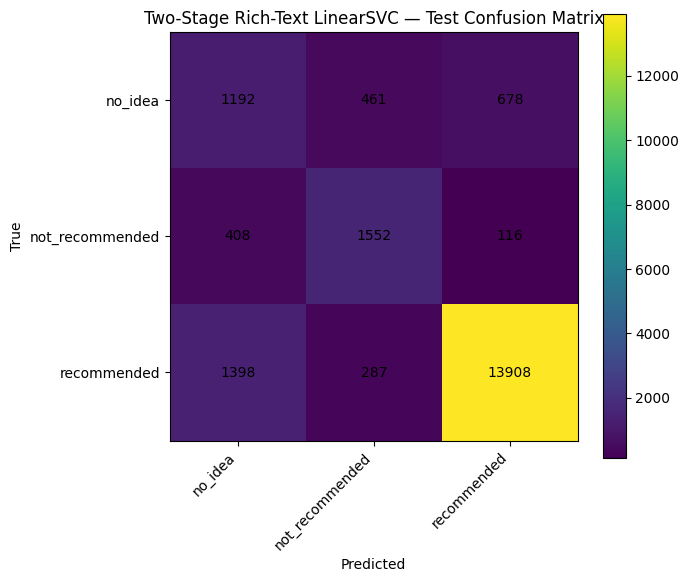

Saved: /content/drive/MyDrive/DigikalaProject/eval/fatemeh/recommendation_classifier_v2/two_stage_rich_svm_test_confusion_matrix.png


In [58]:
import matplotlib.pyplot as plt

TWO_STAGE_CM_PNG = (
    EVAL_DIR
    / "two_stage_rich_svm_test_confusion_matrix.png"
)

plt.figure(figsize=(7, 6))

plt.imshow(
    two_stage_test_cm,
    interpolation="nearest",
)

plt.xticks(
    range(len(LABELS)),
    LABELS,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(LABELS)),
    LABELS,
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title(
    "Two-Stage Rich-Text LinearSVC — Test Confusion Matrix"
)

plt.colorbar()

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        plt.text(
            j,
            i,
            str(two_stage_test_cm[i, j]),
            ha="center",
            va="center",
        )

plt.tight_layout()

plt.savefig(
    TWO_STAGE_CM_PNG,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    TWO_STAGE_CM_PNG
)

In [59]:
RICH_TEST_EMB = (
    RICH_BERT_DIR / "test_rich.npy"
)

In [60]:
if not RICH_TEST_EMB.exists():

    if not torch.cuda.is_available():
        raise RuntimeError(
            "GPU is required for first-time Rich ParsBERT test embedding extraction."
        )

    device = torch.device("cuda")

    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME
    )

    encoder = AutoModel.from_pretrained(
        MODEL_NAME
    ).to(device)

    for parameter in encoder.parameters():
        parameter.requires_grad = False

    extract_rich_embeddings(
        test_rich["parsbert_rich_text"],
        "test",
        RICH_TEST_EMB,
        tokenizer,
        encoder,
        device,
    )

    del encoder, tokenizer

    torch.cuda.empty_cache()
    gc.collect()

else:

    print(
        "Rich ParsBERT test embeddings already cached."
    )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: HooshvareLab/bert-base-parsbert-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


test shard 1/4:   0%|          | 0/79 [00:00<?, ?it/s]

Saved test shard 1/4: (5000, 768)


test shard 2/4:   0%|          | 0/79 [00:00<?, ?it/s]

Saved test shard 2/4: (5000, 768)


test shard 3/4:   0%|          | 0/79 [00:00<?, ?it/s]

Saved test shard 3/4: (5000, 768)


test shard 4/4:   0%|          | 0/79 [00:00<?, ?it/s]

Saved test shard 4/4: (5000, 768)
Saved combined embeddings: /content/drive/MyDrive/DigikalaProject/models/recommendation_classifier_v2/parsbert_rich_embeddings/test_rich.npy


In [61]:
X_test_rich_bert = np.load(
    RICH_TEST_EMB,
    mmap_mode="r",
)

rich_bert_test_pred = (
    best_rich_bert_model.predict(
        np.asarray(
            X_test_rich_bert,
            dtype=np.float32,
        )
    )
)

rich_bert_test_f1 = f1_score(
    y_test,
    rich_bert_test_pred,
    average="macro",
)

print(
    "Rich Frozen ParsBERT Test Macro F1:",
    round(rich_bert_test_f1, 4)
)

Rich Frozen ParsBERT Test Macro F1: 0.6587


In [62]:
rich_bert_test_report_df = pd.DataFrame(
    classification_report(
        y_test,
        rich_bert_test_pred,
        labels=np.arange(len(LABELS)),
        target_names=LABELS,
        output_dict=True,
        zero_division=0,
    )
).T

display(
    rich_bert_test_report_df
)

rich_bert_test_cm = confusion_matrix(
    y_test,
    rich_bert_test_pred,
    labels=np.arange(len(LABELS)),
)

rich_bert_test_cm_df = pd.DataFrame(
    rich_bert_test_cm,
    index=[
        f"true_{x}"
        for x in LABELS
    ],
    columns=[
        f"pred_{x}"
        for x in LABELS
    ],
)

display(
    rich_bert_test_cm_df
)

,precision,recall,f1-score,support
no_idea,0.390540,0.400257,0.395339,2331.0000
not_recommended,0.595867,0.750000,0.664107,2076.0000
recommended,0.934925,0.899250,0.916740,15593.0000
accuracy,0.825600,0.825600,0.825600,0.8256
macro avg,0.640444,0.683169,0.658729,20000.0000
weighted avg,0.836282,0.825600,0.829748,20000.0000


,pred_no_idea,pred_not_recommended,pred_recommended
true_no_idea,933,586,812
true_not_recommended,355,1557,164
true_recommended,1101,470,14022


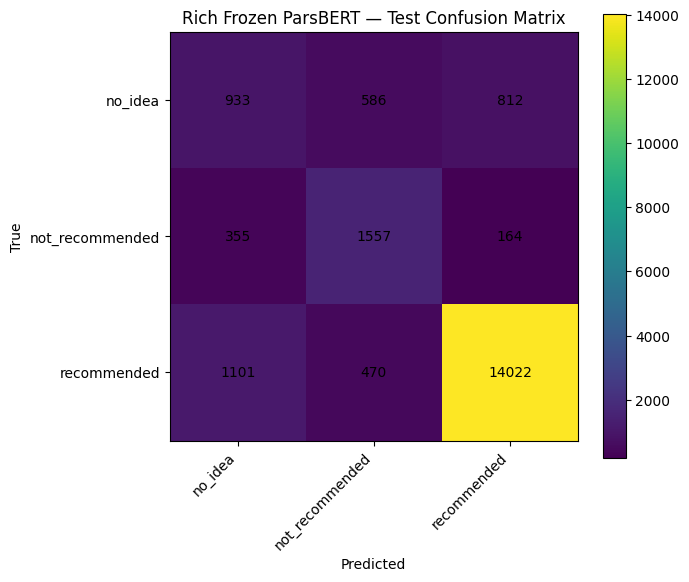

Saved: /content/drive/MyDrive/DigikalaProject/eval/fatemeh/recommendation_classifier_v2/rich_frozen_parsbert_test_confusion_matrix.png


In [63]:
RICH_BERT_TEST_CM_PNG = (
    EVAL_DIR
    / "rich_frozen_parsbert_test_confusion_matrix.png"
)

plt.figure(figsize=(7, 6))

plt.imshow(
    rich_bert_test_cm,
    interpolation="nearest",
)

plt.xticks(
    range(len(LABELS)),
    LABELS,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(LABELS)),
    LABELS,
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title(
    "Rich Frozen ParsBERT — Test Confusion Matrix"
)

plt.colorbar()

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        plt.text(
            j,
            i,
            str(rich_bert_test_cm[i, j]),
            ha="center",
            va="center",
        )

plt.tight_layout()

plt.savefig(
    RICH_BERT_TEST_CM_PNG,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    RICH_BERT_TEST_CM_PNG
)

In [64]:
two_stage_test_report_df.to_csv(
    EVAL_DIR / "two_stage_rich_svm_test_report.csv"
)

two_stage_test_cm_df.to_csv(
    EVAL_DIR / "two_stage_rich_svm_test_confusion_matrix.csv"
)

rich_bert_test_report_df.to_csv(
    EVAL_DIR / "rich_frozen_parsbert_test_report.csv"
)

rich_bert_test_cm_df.to_csv(
    EVAL_DIR / "rich_frozen_parsbert_test_confusion_matrix.csv"
)

In [65]:
final_test_predictions = test_df.copy()

final_test_predictions["true_label"] = (
    le.inverse_transform(y_test)
)

final_test_predictions[
    "tfidf_prediction"
] = le.inverse_transform(
    tfidf_test_pred
)

final_test_predictions[
    "two_stage_rich_svm_prediction"
] = le.inverse_transform(
    two_stage_test_pred
)

final_test_predictions[
    "rich_frozen_parsbert_prediction"
] = le.inverse_transform(
    rich_bert_test_pred
)

final_test_predictions.to_csv(
    EVAL_DIR / "final_test_predictions.csv",
    index=False,
)

print(
    "Saved final test predictions."
)

Saved final test predictions.


In [66]:
final_model_comparison = pd.DataFrame(
    [
        {
            "model": "TF-IDF + Logistic Regression",
            "validation_macro_f1": tfidf_val_f1,
            "test_macro_f1": tfidf_test_f1,
        },
        {
            "model": "Two-Stage Rich-Text LinearSVC",
            "validation_macro_f1": best_two_stage_f1,
            "test_macro_f1": two_stage_test_f1,
        },
        {
            "model": "Rich Frozen ParsBERT + LinearSVC",
            "validation_macro_f1": best_rich_bert_f1,
            "test_macro_f1": rich_bert_test_f1,
        },
    ]
).sort_values(
    "test_macro_f1",
    ascending=False,
).reset_index(drop=True)

display(
    final_model_comparison
)

final_model_comparison.to_csv(
    EVAL_DIR / "final_model_comparison.csv",
    index=False,
)

,model,validation_macro_f1,test_macro_f1
0,Two-Stage Rich-Text LinearSVC,0.693350,0.691619
1,Rich Frozen ParsBERT + LinearSVC,0.648856,0.658729
2,TF-IDF + Logistic Regression,0.649973,0.654291


In [67]:
FINAL_SUMMARY_PATH = (
    EVAL_DIR / "final_mandatory_summary.json"
)

final_summary = {
    "train_rows": len(train_df),
    "validation_rows": len(val_df),
    "test_rows": len(test_df),

    "tfidf_test_macro_f1": float(
        tfidf_test_f1
    ),

    "two_stage_rich_svm_validation_macro_f1": float(
        best_two_stage_f1
    ),

    "two_stage_rich_svm_test_macro_f1": float(
        two_stage_test_f1
    ),

    "rich_frozen_parsbert_validation_macro_f1": float(
        best_rich_bert_f1
    ),

    "rich_frozen_parsbert_test_macro_f1": float(
        rich_bert_test_f1
    ),

    "test_used_for_model_selection": False,
}

FINAL_SUMMARY_PATH.write_text(
    json.dumps(
        final_summary,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    json.dumps(
        final_summary,
        ensure_ascii=False,
        indent=2,
    )
)

{
  "train_rows": 60000,
  "validation_rows": 15000,
  "test_rows": 20000,
  "tfidf_test_macro_f1": 0.6542905909296978,
  "two_stage_rich_svm_validation_macro_f1": 0.6933495330998897,
  "two_stage_rich_svm_test_macro_f1": 0.6916194604697891,
  "rich_frozen_parsbert_validation_macro_f1": 0.6488558802024981,
  "rich_frozen_parsbert_test_macro_f1": 0.6587288954555152,
  "test_used_for_model_selection": false
}


# Bonus Experiment — Lightweight Rich-Text ParsBERT + LoRA

This experiment applies parameter-efficient fine-tuning to ParsBERT.

The original ParsBERT parameters remain frozen. Only LoRA adapters and the classification head are trainable.

To reduce computational cost, a fixed stratified subset of 30,000 training reviews is used. The validation split remains unchanged.

Input:
- title
- advantages
- disadvantages
- review body

Model selection uses Validation Macro F1 only.

In [68]:
import importlib.util
import subprocess
import sys

# Remove an old torchao version if it causes PEFT incompatibility.
if importlib.util.find_spec("torchao") is not None:
    try:
        import torchao
        from packaging.version import Version

        if Version(torchao.__version__) < Version("0.16.0"):
            print("Removing incompatible torchao:", torchao.__version__)

            subprocess.run(
                [
                    sys.executable,
                    "-m",
                    "pip",
                    "uninstall",
                    "-y",
                    "torchao",
                ],
                check=False,
            )

    except Exception:
        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "uninstall",
                "-y",
                "torchao",
            ],
            check=False,
        )


def ensure_lora_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                pip_name or import_name,
            ]
        )


ensure_lora_package("peft", "peft>=0.13")
ensure_lora_package("accelerate", "accelerate>=0.34")

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
)

from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

print("LoRA dependencies ready.")

Removing incompatible torchao: 0.10.0
LoRA dependencies ready.


In [69]:
LIGHT_LORA_DIR = RUN_ROOT / "lora_rich_light_v1"

BEST_LORA_DIR = (
    LIGHT_LORA_DIR / "best_adapter"
)

LAST_LORA_DIR = (
    LIGHT_LORA_DIR / "last_adapter"
)

LORA_HISTORY_PATH = (
    EVAL_DIR / "rich_light_lora_history.csv"
)

LORA_METRICS_PATH = (
    EVAL_DIR / "rich_light_lora_validation_metrics.json"
)

LIGHT_LORA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Lightweight configuration
LORA_TRAIN_N = 30_000

LORA_R = 4
LORA_ALPHA = 8
LORA_DROPOUT = 0.05

LORA_BATCH_SIZE = 8
LORA_VAL_BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 4

LORA_EPOCHS = 2
LORA_LR = 2e-4

LORA_WEIGHT_DECAY = 0.01
LORA_WARMUP_RATIO = 0.06

LORA_MAX_LENGTH = 128

EARLY_STOPPING_PATIENCE = 1


if not torch.cuda.is_available():
    raise RuntimeError(
        "A CUDA GPU is required for LoRA training."
    )

lora_device = torch.device("cuda")

print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

print(
    "Effective batch size:",
    LORA_BATCH_SIZE * GRAD_ACCUM_STEPS
)

print(
    "LoRA rank:",
    LORA_R
)

print(
    "Epochs:",
    LORA_EPOCHS
)

GPU: Tesla T4
Effective batch size: 32
LoRA rank: 4
Epochs: 2


In [70]:
from sklearn.model_selection import train_test_split

required_columns = {
    "parsbert_rich_text",
    "recommendation_status",
}

assert required_columns.issubset(
    train_rich.columns
)

assert required_columns.issubset(
    val_rich.columns
)


if len(train_rich) > LORA_TRAIN_N:

    lora_train_df, _ = train_test_split(
        train_rich,
        train_size=LORA_TRAIN_N,
        stratify=train_rich[
            "recommendation_status"
        ],
        random_state=SEED,
    )

    lora_train_df = (
        lora_train_df
        .reset_index(drop=True)
    )

else:

    lora_train_df = (
        train_rich
        .copy()
        .reset_index(drop=True)
    )


lora_val_df = (
    val_rich
    .copy()
    .reset_index(drop=True)
)


lora_y_train = le.transform(
    lora_train_df[
        "recommendation_status"
    ]
)

lora_y_val = le.transform(
    lora_val_df[
        "recommendation_status"
    ]
)


print(
    "LoRA train rows:",
    len(lora_train_df)
)

print(
    "Validation rows:",
    len(lora_val_df)
)

display(
    lora_train_df[
        "recommendation_status"
    ].value_counts(
        normalize=True
    )
)

LoRA train rows: 30000
Validation rows: 15000


,proportion
recommendation_status,
recommended,0.779100
no_idea,0.117133
not_recommended,0.103767


In [71]:
lora_tokenizer = (
    AutoTokenizer.from_pretrained(
        MODEL_NAME
    )
)


class LoRATextDataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length,
    ):

        self.texts = (
            texts
            .astype(str)
            .tolist()
        )

        self.labels = np.asarray(
            labels,
            dtype=np.int64,
        )

        self.tokenizer = tokenizer
        self.max_length = max_length


    def __len__(self):
        return len(self.labels)


    def __getitem__(self, idx):

        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False,
        )

        encoded["labels"] = int(
            self.labels[idx]
        )

        return encoded


train_lora_dataset = LoRATextDataset(
    lora_train_df[
        "parsbert_rich_text"
    ],
    lora_y_train,
    lora_tokenizer,
    LORA_MAX_LENGTH,
)

val_lora_dataset = LoRATextDataset(
    lora_val_df[
        "parsbert_rich_text"
    ],
    lora_y_val,
    lora_tokenizer,
    LORA_MAX_LENGTH,
)


lora_collator = DataCollatorWithPadding(
    tokenizer=lora_tokenizer,
    pad_to_multiple_of=8,
)


train_lora_loader = DataLoader(
    train_lora_dataset,
    batch_size=LORA_BATCH_SIZE,
    shuffle=True,
    collate_fn=lora_collator,
    num_workers=0,
    pin_memory=True,
)

val_lora_loader = DataLoader(
    val_lora_dataset,
    batch_size=LORA_VAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=lora_collator,
    num_workers=0,
    pin_memory=True,
)


print(
    "Train batches:",
    len(train_lora_loader)
)

print(
    "Validation batches:",
    len(val_lora_loader)
)

Train batches: 3750
Validation batches: 469


In [72]:
gc.collect()
torch.cuda.empty_cache()


id2label = {
    i: label
    for i, label
    in enumerate(LABELS)
}

label2id = {
    label: i
    for i, label
    in enumerate(LABELS)
}


base_lora_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=len(LABELS),
        id2label=id2label,
        label2id=label2id,
    )
)


lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,

    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,

    target_modules=[
        "query",
        "value",
    ],

    bias="none",

    modules_to_save=[
        "classifier",
    ],
)


lora_model = get_peft_model(
    base_lora_model,
    lora_config,
)

lora_model = lora_model.to(
    lora_device
)


trainable_params = sum(
    p.numel()
    for p in lora_model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in lora_model.parameters()
)


print(
    f"Total parameters: {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)

print(
    "Trainable percentage:",
    round(
        100
        * trainable_params
        / total_params,
        4,
    ),
    "%",
)

lora_model.print_trainable_parameters()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-base-parsbert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

Total parameters: 162,993,414
Trainable parameters: 149,763
Trainable percentage: 0.0919 %
trainable params: 149,763 || all params: 162,993,414 || trainable%: 0.0919


In [73]:
class_counts = np.bincount(
    lora_y_train,
    minlength=len(LABELS),
)

class_weights = (
    len(lora_y_train)
    / (
        len(LABELS)
        * class_counts
    )
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=lora_device,
)


print(
    "Class counts:",
    dict(
        zip(
            LABELS,
            class_counts.tolist(),
        )
    )
)

print(
    "Class weights:",
    dict(
        zip(
            LABELS,
            class_weights
            .detach()
            .cpu()
            .numpy()
            .round(3)
            .tolist(),
        )
    )
)


criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights
)


optimizer = torch.optim.AdamW(
    [
        p
        for p in lora_model.parameters()
        if p.requires_grad
    ],
    lr=LORA_LR,
    weight_decay=LORA_WEIGHT_DECAY,
)


optimizer_steps_per_epoch = (
    len(train_lora_loader)
    + GRAD_ACCUM_STEPS
    - 1
) // GRAD_ACCUM_STEPS


total_optimizer_steps = (
    optimizer_steps_per_epoch
    * LORA_EPOCHS
)


warmup_steps = int(
    LORA_WARMUP_RATIO
    * total_optimizer_steps
)


scheduler = (
    get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_optimizer_steps,
    )
)


print(
    "Optimizer steps:",
    total_optimizer_steps
)

print(
    "Warmup steps:",
    warmup_steps
)

Class counts: {'no_idea': 3514, 'not_recommended': 3113, 'recommended': 23373}
Class weights: {'no_idea': 2.8459999561309814, 'not_recommended': 3.2119998931884766, 'recommended': 0.42800000309944153}
Optimizer steps: 1876
Warmup steps: 112


In [74]:
lora_model.train()

preflight_batch = next(
    iter(train_lora_loader)
)

preflight_labels = (
    preflight_batch
    .pop("labels")
    .to(lora_device)
)

preflight_batch = {
    key: value.to(
        lora_device,
        non_blocking=True,
    )
    for key, value
    in preflight_batch.items()
}


optimizer.zero_grad(
    set_to_none=True
)


with torch.autocast(
    device_type="cuda",
    dtype=torch.float16,
):

    outputs = lora_model(
        **preflight_batch
    )

    preflight_loss = criterion(
        outputs.logits,
        preflight_labels,
    )


preflight_loss.backward()


lora_gradients = [
    p.grad
    for name, p
    in lora_model.named_parameters()
    if (
        "lora_" in name
        and p.grad is not None
    )
]


if not lora_gradients:
    raise RuntimeError(
        "No LoRA gradients were produced."
    )


if not all(
    torch.isfinite(g).all()
    for g in lora_gradients
):
    raise RuntimeError(
        "Non-finite LoRA gradient detected."
    )


print(
    "Preflight loss:",
    float(
        preflight_loss.detach().cpu()
    )
)

print(
    "LoRA gradient check passed."
)


optimizer.zero_grad(
    set_to_none=True
)

del preflight_batch
del preflight_labels
del outputs
del preflight_loss
del lora_gradients

torch.cuda.empty_cache()
gc.collect()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Preflight loss: 0.9665065407752991
LoRA gradient check passed.


104

In [75]:
@torch.no_grad()
def evaluate_lora(
    model,
    loader,
    y_true,
):

    model.eval()

    predictions = []

    for batch in tqdm(
        loader,
        desc="Validation",
        leave=False,
    ):

        labels = batch.pop(
            "labels"
        )

        batch = {
            key: value.to(
                lora_device,
                non_blocking=True,
            )
            for key, value
            in batch.items()
        }

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        ):

            logits = model(
                **batch
            ).logits

        pred = (
            logits
            .argmax(dim=-1)
            .detach()
            .cpu()
            .numpy()
        )

        predictions.append(
            pred
        )


    predictions = np.concatenate(
        predictions
    )

    macro_f1 = f1_score(
        y_true,
        predictions,
        average="macro",
    )

    return (
        macro_f1,
        predictions,
    )

In [76]:
scaler = torch.cuda.amp.GradScaler()

history = []

best_lora_val_f1 = -1.0
best_lora_val_pred = None

epochs_without_improvement = 0


for epoch in range(
    1,
    LORA_EPOCHS + 1,
):

    print(
        f"\n===== Epoch {epoch}/{LORA_EPOCHS} ====="
    )

    lora_model.train()

    optimizer.zero_grad(
        set_to_none=True
    )

    running_loss = 0.0


    progress = tqdm(
        train_lora_loader,
        desc=f"Train epoch {epoch}",
    )


    for step, batch in enumerate(
        progress,
        start=1,
    ):

        labels = (
            batch
            .pop("labels")
            .to(
                lora_device,
                non_blocking=True,
            )
        )

        batch = {
            key: value.to(
                lora_device,
                non_blocking=True,
            )
            for key, value
            in batch.items()
        }


        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        ):

            logits = lora_model(
                **batch
            ).logits

            loss = criterion(
                logits,
                labels,
            )

            loss = (
                loss
                / GRAD_ACCUM_STEPS
            )


        scaler.scale(
            loss
        ).backward()


        running_loss += (
            loss.item()
            * GRAD_ACCUM_STEPS
        )


        should_step = (
            step % GRAD_ACCUM_STEPS == 0
            or step == len(
                train_lora_loader
            )
        )


        if should_step:

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                [
                    p
                    for p
                    in lora_model.parameters()
                    if p.requires_grad
                ],
                max_norm=1.0,
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )

            scheduler.step()


        progress.set_postfix(
            loss=round(
                running_loss / step,
                4,
            )
        )


    train_loss = (
        running_loss
        / len(train_lora_loader)
    )


    val_f1, val_pred = evaluate_lora(
        lora_model,
        val_lora_loader,
        lora_y_val,
    )


    print(
        f"Epoch {epoch} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Validation Macro F1: {val_f1:.4f}"
    )


    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_macro_f1": val_f1,
        }
    )


    pd.DataFrame(
        history
    ).to_csv(
        LORA_HISTORY_PATH,
        index=False,
    )


    # Always save the completed epoch.
    lora_model.save_pretrained(
        LAST_LORA_DIR
    )


    if val_f1 > best_lora_val_f1:

        best_lora_val_f1 = val_f1

        best_lora_val_pred = (
            val_pred.copy()
        )

        lora_model.save_pretrained(
            BEST_LORA_DIR
        )

        lora_tokenizer.save_pretrained(
            BEST_LORA_DIR
        )

        epochs_without_improvement = 0

        print(
            "Best LoRA adapter saved."
        )

    else:

        epochs_without_improvement += 1

        print(
            "No validation improvement."
        )


    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "Early stopping."
        )

        break


print()
print(
    "Best LoRA Validation Macro F1:",
    round(
        best_lora_val_f1,
        4,
    )
)

print(
    "Best adapter:",
    BEST_LORA_DIR
)


===== Epoch 1/2 =====


/tmp/ipykernel_1571/1184560707.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Train epoch 1:   0%|          | 0/3750 [00:00<?, ?it/s]

Validation:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.7503 | Validation Macro F1: 0.6886
Best LoRA adapter saved.

===== Epoch 2/2 =====


Train epoch 2:   0%|          | 0/3750 [00:00<?, ?it/s]

Validation:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.6172 | Validation Macro F1: 0.6911
Best LoRA adapter saved.

Best LoRA Validation Macro F1: 0.6911
Best adapter: /content/drive/MyDrive/DigikalaProject/models/recommendation_classifier_v2/lora_rich_light_v1/best_adapter


# Extended Experiment — Rich-Text ParsBERT + LoRA on Full Training Data

The lightweight LoRA experiment showed that parameter-efficient fine-tuning is competitive with the strongest classical baseline.

This experiment increases the training data from 30,000 reviews to the complete 60,000-review training split while keeping the LoRA configuration lightweight.

Configuration:
- Training samples: 60,000
- Validation samples: 15,000
- LoRA rank: 4
- Maximum sequence length: 128
- Effective batch size: 32
- Maximum epochs: 3

The model is initialized again from the original ParsBERT checkpoint rather than continuing from the previous 30k adapter. This allows the effect of additional training data to be evaluated independently.

Model selection is based only on Validation Macro F1.

In [77]:
FULL_LORA_DIR = RUN_ROOT / "lora_rich_full60k_v1"

FULL_BEST_LORA_DIR = (
    FULL_LORA_DIR / "best_adapter"
)

FULL_LAST_LORA_DIR = (
    FULL_LORA_DIR / "last_adapter"
)

FULL_LORA_HISTORY_PATH = (
    EVAL_DIR / "rich_full60k_lora_history.csv"
)

FULL_LORA_METRICS_PATH = (
    EVAL_DIR / "rich_full60k_lora_validation_metrics.json"
)

FULL_LORA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


FULL_LORA_R = 4
FULL_LORA_ALPHA = 8
FULL_LORA_DROPOUT = 0.05

FULL_LORA_BATCH_SIZE = 8
FULL_LORA_VAL_BATCH_SIZE = 32
FULL_GRAD_ACCUM_STEPS = 4

FULL_LORA_EPOCHS = 3

FULL_LORA_LR = 2e-4
FULL_LORA_WEIGHT_DECAY = 0.01
FULL_LORA_WARMUP_RATIO = 0.06

FULL_LORA_MAX_LENGTH = 128

# Allow one temporary non-improving epoch.
FULL_EARLY_STOPPING_PATIENCE = 2


print("Training rows:", len(train_rich))
print("Validation rows:", len(val_rich))

print(
    "Effective batch size:",
    FULL_LORA_BATCH_SIZE
    * FULL_GRAD_ACCUM_STEPS
)

print("LoRA rank:", FULL_LORA_R)
print("Maximum epochs:", FULL_LORA_EPOCHS)

Training rows: 60000
Validation rows: 15000
Effective batch size: 32
LoRA rank: 4
Maximum epochs: 3


In [78]:
try:
    del lora_model
except NameError:
    pass

try:
    del base_lora_model
except NameError:
    pass

try:
    del optimizer
except NameError:
    pass

try:
    del scheduler
except NameError:
    pass

try:
    del scaler
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

print(
    "GPU memory allocated:",
    round(
        torch.cuda.memory_allocated()
        / 1024**3,
        3,
    ),
    "GB",
)

GPU memory allocated: 0.017 GB


In [79]:
full_lora_train_df = (
    train_rich
    .copy()
    .reset_index(drop=True)
)

full_lora_val_df = (
    val_rich
    .copy()
    .reset_index(drop=True)
)


full_lora_y_train = le.transform(
    full_lora_train_df[
        "recommendation_status"
    ]
)

full_lora_y_val = le.transform(
    full_lora_val_df[
        "recommendation_status"
    ]
)


assert len(full_lora_train_df) == 60_000
assert len(full_lora_val_df) == 15_000


print(
    "Full LoRA train:",
    len(full_lora_train_df)
)

print(
    "Validation:",
    len(full_lora_val_df)
)

display(
    full_lora_train_df[
        "recommendation_status"
    ].value_counts(
        normalize=True
    )
)

Full LoRA train: 60000
Validation: 15000


,proportion
recommendation_status,
recommended,0.779100
no_idea,0.117133
not_recommended,0.103767


In [80]:
full_train_lora_dataset = LoRATextDataset(
    full_lora_train_df[
        "parsbert_rich_text"
    ],
    full_lora_y_train,
    lora_tokenizer,
    FULL_LORA_MAX_LENGTH,
)

full_val_lora_dataset = LoRATextDataset(
    full_lora_val_df[
        "parsbert_rich_text"
    ],
    full_lora_y_val,
    lora_tokenizer,
    FULL_LORA_MAX_LENGTH,
)


full_train_lora_loader = DataLoader(
    full_train_lora_dataset,
    batch_size=FULL_LORA_BATCH_SIZE,
    shuffle=True,
    collate_fn=lora_collator,
    num_workers=0,
    pin_memory=True,
)

full_val_lora_loader = DataLoader(
    full_val_lora_dataset,
    batch_size=FULL_LORA_VAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=lora_collator,
    num_workers=0,
    pin_memory=True,
)


print(
    "Train batches:",
    len(full_train_lora_loader)
)

print(
    "Validation batches:",
    len(full_val_lora_loader)
)

Train batches: 7500
Validation batches: 469


In [81]:
import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


gc.collect()
torch.cuda.empty_cache()


full_base_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=len(LABELS),
        id2label=id2label,
        label2id=label2id,
    )
)


full_lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,

    r=FULL_LORA_R,
    lora_alpha=FULL_LORA_ALPHA,
    lora_dropout=FULL_LORA_DROPOUT,

    target_modules=[
        "query",
        "value",
    ],

    bias="none",

    modules_to_save=[
        "classifier",
    ],
)


full_lora_model = get_peft_model(
    full_base_model,
    full_lora_config,
)

full_lora_model = full_lora_model.to(
    lora_device
)


full_trainable_params = sum(
    p.numel()
    for p in full_lora_model.parameters()
    if p.requires_grad
)

full_total_params = sum(
    p.numel()
    for p in full_lora_model.parameters()
)


print(
    "Trainable parameters:",
    f"{full_trainable_params:,}",
)

print(
    "Trainable percentage:",
    round(
        100
        * full_trainable_params
        / full_total_params,
        4,
    ),
    "%",
)

full_lora_model.print_trainable_parameters()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-base-parsbert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

Trainable parameters: 149,763
Trainable percentage: 0.0919 %
trainable params: 149,763 || all params: 162,993,414 || trainable%: 0.0919


In [82]:
full_class_counts = np.bincount(
    full_lora_y_train,
    minlength=len(LABELS),
)


full_class_weights = (
    len(full_lora_y_train)
    / (
        len(LABELS)
        * full_class_counts
    )
)


full_class_weights = torch.tensor(
    full_class_weights,
    dtype=torch.float32,
    device=lora_device,
)


print(
    "Class counts:",
    dict(
        zip(
            LABELS,
            full_class_counts.tolist(),
        )
    )
)

print(
    "Class weights:",
    dict(
        zip(
            LABELS,
            full_class_weights
            .detach()
            .cpu()
            .numpy()
            .round(3)
            .tolist(),
        )
    )
)


full_criterion = (
    torch.nn.CrossEntropyLoss(
        weight=full_class_weights
    )
)


full_optimizer = torch.optim.AdamW(
    [
        p
        for p
        in full_lora_model.parameters()
        if p.requires_grad
    ],
    lr=FULL_LORA_LR,
    weight_decay=FULL_LORA_WEIGHT_DECAY,
)


full_optimizer_steps_per_epoch = (
    len(full_train_lora_loader)
    + FULL_GRAD_ACCUM_STEPS
    - 1
) // FULL_GRAD_ACCUM_STEPS


full_total_optimizer_steps = (
    full_optimizer_steps_per_epoch
    * FULL_LORA_EPOCHS
)


full_warmup_steps = int(
    FULL_LORA_WARMUP_RATIO
    * full_total_optimizer_steps
)


full_scheduler = (
    get_linear_schedule_with_warmup(
        full_optimizer,
        num_warmup_steps=full_warmup_steps,
        num_training_steps=full_total_optimizer_steps,
    )
)


print(
    "Optimizer steps:",
    full_total_optimizer_steps
)

print(
    "Warmup steps:",
    full_warmup_steps
)

Class counts: {'no_idea': 7028, 'not_recommended': 6226, 'recommended': 46746}
Class weights: {'no_idea': 2.8459999561309814, 'not_recommended': 3.2119998931884766, 'recommended': 0.42800000309944153}
Optimizer steps: 5625
Warmup steps: 337


In [83]:
full_lora_model.train()

preflight_batch = next(
    iter(full_train_lora_loader)
)

preflight_labels = (
    preflight_batch
    .pop("labels")
    .to(lora_device)
)

preflight_batch = {
    key: value.to(
        lora_device,
        non_blocking=True,
    )
    for key, value
    in preflight_batch.items()
}


full_optimizer.zero_grad(
    set_to_none=True
)


with torch.autocast(
    device_type="cuda",
    dtype=torch.float16,
):

    outputs = full_lora_model(
        **preflight_batch
    )

    preflight_loss = full_criterion(
        outputs.logits,
        preflight_labels,
    )


preflight_loss.backward()


lora_gradients = [
    p.grad
    for name, p
    in full_lora_model.named_parameters()
    if (
        "lora_" in name
        and p.grad is not None
    )
]


assert len(lora_gradients) > 0

assert all(
    torch.isfinite(g).all()
    for g in lora_gradients
)


print(
    "Preflight loss:",
    float(
        preflight_loss
        .detach()
        .cpu()
    )
)

print(
    "Full 60k LoRA gradient check passed."
)


full_optimizer.zero_grad(
    set_to_none=True
)

del preflight_batch
del preflight_labels
del outputs
del preflight_loss
del lora_gradients

torch.cuda.empty_cache()
gc.collect()

Preflight loss: 0.7850341200828552
Full 60k LoRA gradient check passed.


206

In [84]:
@torch.no_grad()
def evaluate_full_lora(
    model,
    loader,
    y_true,
):

    model.eval()

    predictions = []

    for batch in tqdm(
        loader,
        desc="Validation",
        leave=False,
    ):

        batch.pop("labels")

        batch = {
            key: value.to(
                lora_device,
                non_blocking=True,
            )
            for key, value
            in batch.items()
        }

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        ):

            logits = model(
                **batch
            ).logits


        predictions.append(
            logits
            .argmax(dim=-1)
            .detach()
            .cpu()
            .numpy()
        )


    predictions = np.concatenate(
        predictions
    )


    macro_f1 = f1_score(
        y_true,
        predictions,
        average="macro",
    )


    return macro_f1, predictions

In [85]:
full_scaler = torch.cuda.amp.GradScaler()

full_history = []

best_full_lora_val_f1 = -1.0
best_full_lora_val_pred = None

epochs_without_improvement = 0


for epoch in range(
    1,
    FULL_LORA_EPOCHS + 1,
):

    print(
        f"\n===== Full 60k Epoch "
        f"{epoch}/{FULL_LORA_EPOCHS} ====="
    )


    full_lora_model.train()

    full_optimizer.zero_grad(
        set_to_none=True
    )

    running_loss = 0.0


    progress = tqdm(
        full_train_lora_loader,
        desc=f"Full train epoch {epoch}",
    )


    for step, batch in enumerate(
        progress,
        start=1,
    ):

        labels = (
            batch
            .pop("labels")
            .to(
                lora_device,
                non_blocking=True,
            )
        )


        batch = {
            key: value.to(
                lora_device,
                non_blocking=True,
            )
            for key, value
            in batch.items()
        }


        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        ):

            logits = full_lora_model(
                **batch
            ).logits

            loss = full_criterion(
                logits,
                labels,
            )

            scaled_loss = (
                loss
                / FULL_GRAD_ACCUM_STEPS
            )


        full_scaler.scale(
            scaled_loss
        ).backward()


        running_loss += loss.item()


        should_step = (
            step % FULL_GRAD_ACCUM_STEPS == 0
            or step == len(
                full_train_lora_loader
            )
        )


        if should_step:

            full_scaler.unscale_(
                full_optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                [
                    p
                    for p
                    in full_lora_model.parameters()
                    if p.requires_grad
                ],
                max_norm=1.0,
            )


            full_scaler.step(
                full_optimizer
            )

            full_scaler.update()

            full_optimizer.zero_grad(
                set_to_none=True
            )

            full_scheduler.step()


        progress.set_postfix(
            loss=round(
                running_loss / step,
                4,
            )
        )


    train_loss = (
        running_loss
        / len(full_train_lora_loader)
    )


    val_f1, val_pred = evaluate_full_lora(
        full_lora_model,
        full_val_lora_loader,
        full_lora_y_val,
    )


    print(
        f"Epoch {epoch}"
        f" | Train Loss: {train_loss:.4f}"
        f" | Validation Macro F1: {val_f1:.4f}"
    )


    full_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_macro_f1": val_f1,
        }
    )


    pd.DataFrame(
        full_history
    ).to_csv(
        FULL_LORA_HISTORY_PATH,
        index=False,
    )


    full_lora_model.save_pretrained(
        FULL_LAST_LORA_DIR
    )


    if val_f1 > best_full_lora_val_f1:

        best_full_lora_val_f1 = val_f1

        best_full_lora_val_pred = (
            val_pred.copy()
        )

        full_lora_model.save_pretrained(
            FULL_BEST_LORA_DIR
        )

        lora_tokenizer.save_pretrained(
            FULL_BEST_LORA_DIR
        )

        epochs_without_improvement = 0

        print(
            "Best Full-60k LoRA adapter saved."
        )

    else:

        epochs_without_improvement += 1

        print(
            "No validation improvement."
        )


    if (
        epochs_without_improvement
        >= FULL_EARLY_STOPPING_PATIENCE
    ):

        print(
            "Early stopping."
        )

        break


print()
print(
    "Best Full-60k LoRA Validation Macro F1:",
    round(
        best_full_lora_val_f1,
        4,
    )
)

print(
    "Best adapter:",
    FULL_BEST_LORA_DIR
)


===== Full 60k Epoch 1/3 =====


/tmp/ipykernel_1571/1412437591.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  full_scaler = torch.cuda.amp.GradScaler()


Full train epoch 1:   0%|          | 0/7500 [00:00<?, ?it/s]

Validation:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.7075 | Validation Macro F1: 0.6766
Best Full-60k LoRA adapter saved.

===== Full 60k Epoch 2/3 =====


...

Validation:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.5951 | Validation Macro F1: 0.6967
Best Full-60k LoRA adapter saved.

===== Full 60k Epoch 3/3 =====


Full train epoch 3:   0%|          | 0/7500 [00:00<?, ?it/s]

Validation:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3 | Train Loss: 0.5748 | Validation Macro F1: 0.7020
Best Full-60k LoRA adapter saved.

Best Full-60k LoRA Validation Macro F1: 0.702
Best adapter: /content/drive/MyDrive/DigikalaProject/models/recommendation_classifier_v2/lora_rich_full60k_v1/best_adapter


## LoRA Fine-Tuning Phase 2

Validation Macro F1 continued to improve through all three initial epochs.

A short second fine-tuning phase is therefore performed from the best
60k LoRA checkpoint using a lower learning rate.

This phase keeps the same training and validation data while reducing the
learning rate to allow smaller parameter updates near the current optimum.

The best checkpoint continues to be selected using Validation Macro F1 only.

In [86]:
EXTRA_LORA_EPOCHS = 2
EXTRA_LORA_LR = 1e-4

EXTRA_HISTORY_PATH = (
    EVAL_DIR / "rich_full60k_lora_phase2_history.csv"
)

extra_optimizer = torch.optim.AdamW(
    [
        p
        for p in full_lora_model.parameters()
        if p.requires_grad
    ],
    lr=EXTRA_LORA_LR,
    weight_decay=FULL_LORA_WEIGHT_DECAY,
)

extra_steps_per_epoch = (
    len(full_train_lora_loader)
    + FULL_GRAD_ACCUM_STEPS
    - 1
) // FULL_GRAD_ACCUM_STEPS

extra_total_steps = (
    extra_steps_per_epoch
    * EXTRA_LORA_EPOCHS
)

extra_warmup_steps = int(
    0.03 * extra_total_steps
)

extra_scheduler = get_linear_schedule_with_warmup(
    extra_optimizer,
    num_warmup_steps=extra_warmup_steps,
    num_training_steps=extra_total_steps,
)

extra_scaler = torch.cuda.amp.GradScaler()

print("Starting Phase 2")
print("Current best Validation Macro F1:", best_full_lora_val_f1)
print("Learning rate:", EXTRA_LORA_LR)
print("Extra epochs:", EXTRA_LORA_EPOCHS)

Starting Phase 2
Current best Validation Macro F1: 0.7019760798958322
Learning rate: 0.0001
Extra epochs: 2


/tmp/ipykernel_1571/619039314.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  extra_scaler = torch.cuda.amp.GradScaler()


In [87]:
extra_history = []

for extra_epoch in range(
    1,
    EXTRA_LORA_EPOCHS + 1,
):

    global_epoch = FULL_LORA_EPOCHS + extra_epoch

    print(
        f"\n===== Full 60k Phase 2 "
        f"Epoch {global_epoch} ====="
    )

    full_lora_model.train()

    extra_optimizer.zero_grad(
        set_to_none=True
    )

    running_loss = 0.0

    progress = tqdm(
        full_train_lora_loader,
        desc=f"Phase 2 epoch {global_epoch}",
    )

    for step, batch in enumerate(
        progress,
        start=1,
    ):

        labels = (
            batch.pop("labels")
            .to(
                lora_device,
                non_blocking=True,
            )
        )

        batch = {
            key: value.to(
                lora_device,
                non_blocking=True,
            )
            for key, value
            in batch.items()
        }

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        ):

            logits = full_lora_model(
                **batch
            ).logits

            loss = full_criterion(
                logits,
                labels,
            )

            scaled_loss = (
                loss
                / FULL_GRAD_ACCUM_STEPS
            )

        extra_scaler.scale(
            scaled_loss
        ).backward()

        running_loss += loss.item()

        should_step = (
            step % FULL_GRAD_ACCUM_STEPS == 0
            or step == len(full_train_lora_loader)
        )

        if should_step:

            extra_scaler.unscale_(
                extra_optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                [
                    p
                    for p in full_lora_model.parameters()
                    if p.requires_grad
                ],
                max_norm=1.0,
            )

            extra_scaler.step(
                extra_optimizer
            )

            extra_scaler.update()

            extra_optimizer.zero_grad(
                set_to_none=True
            )

            extra_scheduler.step()

        progress.set_postfix(
            loss=round(
                running_loss / step,
                4,
            )
        )

    train_loss = (
        running_loss
        / len(full_train_lora_loader)
    )

    val_f1, val_pred = evaluate_full_lora(
        full_lora_model,
        full_val_lora_loader,
        full_lora_y_val,
    )

    print(
        f"Epoch {global_epoch}"
        f" | Train Loss: {train_loss:.4f}"
        f" | Validation Macro F1: {val_f1:.4f}"
    )

    extra_history.append(
        {
            "epoch": global_epoch,
            "train_loss": train_loss,
            "validation_macro_f1": val_f1,
        }
    )

    pd.DataFrame(
        extra_history
    ).to_csv(
        EXTRA_HISTORY_PATH,
        index=False,
    )

    if val_f1 > best_full_lora_val_f1:

        best_full_lora_val_f1 = val_f1
        best_full_lora_val_pred = val_pred.copy()

        full_lora_model.save_pretrained(
            FULL_BEST_LORA_DIR
        )

        lora_tokenizer.save_pretrained(
            FULL_BEST_LORA_DIR
        )

        print(
            "New best Full-60k LoRA adapter saved."
        )

    else:

        print(
            "No improvement over current best."
        )

        # Stop immediately if the first extra epoch
        # no longer improves validation performance.
        break


print()
print(
    "Final Best Validation Macro F1:",
    round(
        best_full_lora_val_f1,
        4,
    )
)


===== Full 60k Phase 2 Epoch 4 =====


Phase 2 epoch 4:   0%|          | 0/7500 [00:00<?, ?it/s]

Validation:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 4 | Train Loss: 0.5727 | Validation Macro F1: 0.7071
New best Full-60k LoRA adapter saved.

===== Full 60k Phase 2 Epoch 5 =====


Phase 2 epoch 5:   0%|          | 0/7500 [00:00<?, ?it/s]

Validation:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5 | Train Loss: 0.5639 | Validation Macro F1: 0.7038
No improvement over current best.

Final Best Validation Macro F1: 0.7071


In [88]:
from peft import PeftModel

gc.collect()
torch.cuda.empty_cache()

try:
    del full_lora_model
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()


best_base_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=len(LABELS),
        id2label=id2label,
        label2id=label2id,
    )
)

best_full_lora_model = PeftModel.from_pretrained(
    best_base_model,
    FULL_BEST_LORA_DIR,
)

best_full_lora_model = best_full_lora_model.to(
    lora_device
)

best_full_lora_model.eval()

print("Best LoRA adapter loaded:")
print(FULL_BEST_LORA_DIR)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-base-parsbert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

Best LoRA adapter loaded:
/content/drive/MyDrive/DigikalaProject/models/recommendation_classifier_v2/lora_rich_full60k_v1/best_adapter


In [89]:
best_lora_val_f1, best_lora_val_pred = evaluate_full_lora(
    best_full_lora_model,
    full_val_lora_loader,
    full_lora_y_val,
)

print(
    "Best LoRA Validation Macro F1:",
    round(best_lora_val_f1, 4)
)

print()

print(
    classification_report(
        full_lora_y_val,
        best_lora_val_pred,
        labels=np.arange(len(LABELS)),
        target_names=LABELS,
        digits=4,
        zero_division=0,
    )
)

Validation:   0%|          | 0/469 [00:00<?, ?it/s]

Best LoRA Validation Macro F1: 0.7071

                 precision    recall  f1-score   support

        no_idea     0.3844    0.5965    0.4675      1730
not_recommended     0.7235    0.7541    0.7385      1537
    recommended     0.9590    0.8756    0.9154     11733

       accuracy                         0.8310     15000
      macro avg     0.6889    0.7421    0.7071     15000
   weighted avg     0.8686    0.8310    0.8456     15000



In [90]:
best_lora_val_cm = confusion_matrix(
    full_lora_y_val,
    best_lora_val_pred,
    labels=np.arange(len(LABELS)),
)

best_lora_val_cm_df = pd.DataFrame(
    best_lora_val_cm,
    index=[
        f"true_{label}"
        for label in LABELS
    ],
    columns=[
        f"pred_{label}"
        for label in LABELS
    ],
)

display(best_lora_val_cm_df)

,pred_no_idea,pred_not_recommended,pred_recommended
true_no_idea,1032,306,392
true_not_recommended,331,1159,47
true_recommended,1322,137,10274


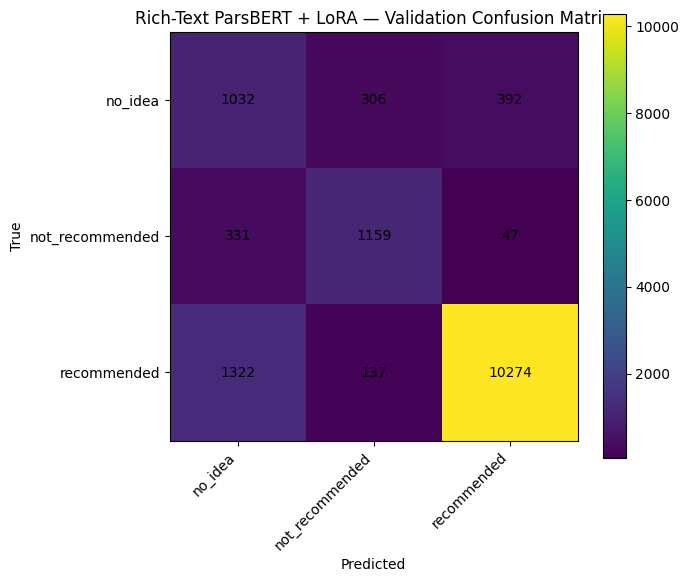

In [91]:
plt.figure(figsize=(7, 6))

plt.imshow(
    best_lora_val_cm,
    interpolation="nearest",
)

plt.xticks(
    range(len(LABELS)),
    LABELS,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(LABELS)),
    LABELS,
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title(
    "Rich-Text ParsBERT + LoRA — Validation Confusion Matrix"
)

plt.colorbar()

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        plt.text(
            j,
            i,
            str(best_lora_val_cm[i, j]),
            ha="center",
            va="center",
        )

plt.tight_layout()

plt.savefig(
    EVAL_DIR / "rich_full60k_lora_validation_confusion_matrix.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [92]:
test_lora_dataset = LoRATextDataset(
    test_rich[
        "parsbert_rich_text"
    ],
    y_test,
    lora_tokenizer,
    FULL_LORA_MAX_LENGTH,
)

test_lora_loader = DataLoader(
    test_lora_dataset,
    batch_size=FULL_LORA_VAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=lora_collator,
    num_workers=0,
    pin_memory=True,
)

print(
    "Test batches:",
    len(test_lora_loader)
)

Test batches: 625


In [93]:
lora_test_f1, lora_test_pred = evaluate_full_lora(
    best_full_lora_model,
    test_lora_loader,
    y_test,
)

print(
    "Final LoRA Test Macro F1:",
    round(lora_test_f1, 4)
)

Validation:   0%|          | 0/625 [00:00<?, ?it/s]

Final LoRA Test Macro F1: 0.7042


In [94]:
lora_test_report = classification_report(
    y_test,
    lora_test_pred,
    labels=np.arange(len(LABELS)),
    target_names=LABELS,
    digits=4,
    zero_division=0,
)

print(lora_test_report)


lora_test_cm = confusion_matrix(
    y_test,
    lora_test_pred,
    labels=np.arange(len(LABELS)),
)

lora_test_cm_df = pd.DataFrame(
    lora_test_cm,
    index=[
        f"true_{label}"
        for label in LABELS
    ],
    columns=[
        f"pred_{label}"
        for label in LABELS
    ],
)

display(lora_test_cm_df)

                 precision    recall  f1-score   support

        no_idea     0.3835    0.5852    0.4633      2331
not_recommended     0.7100    0.7606    0.7344      2076
    recommended     0.9591    0.8746    0.9149     15593

       accuracy                         0.8290     20000
      macro avg     0.6842    0.7401    0.7042     20000
   weighted avg     0.8662    0.8290    0.8436     20000



,pred_no_idea,pred_not_recommended,pred_recommended
true_no_idea,1364,448,519
true_not_recommended,435,1579,62
true_recommended,1758,197,13638


In [95]:
final_model_comparison = pd.DataFrame([
    {
        "model": "TF-IDF + Logistic Regression",
        "validation_macro_f1": tfidf_val_f1,
        "test_macro_f1": tfidf_test_f1,
    },
    {
        "model": "Two-Stage Rich-Text LinearSVC",
        "validation_macro_f1": best_two_stage_f1,
        "test_macro_f1": two_stage_test_f1,
    },
    {
        "model": "Rich Frozen ParsBERT + LinearSVC",
        "validation_macro_f1": best_rich_bert_f1,
        "test_macro_f1": rich_bert_test_f1,
    },
    {
        "model": "Rich ParsBERT + LoRA",
        "validation_macro_f1": best_full_lora_val_f1,
        "test_macro_f1": lora_test_f1,
    },
])

final_model_comparison = (
    final_model_comparison
    .sort_values(
        "validation_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(final_model_comparison)

final_model_comparison.to_csv(
    EVAL_DIR / "final_model_comparison.csv",
    index=False,
)

,model,validation_macro_f1,test_macro_f1
0,Rich ParsBERT + LoRA,0.707130,0.704222
1,Two-Stage Rich-Text LinearSVC,0.693350,0.691619
2,TF-IDF + Logistic Regression,0.649973,0.654291
3,Rich Frozen ParsBERT + LinearSVC,0.648856,0.658729


In [96]:
best_final_model_name = (
    final_model_comparison.iloc[0]["model"]
)

best_final_val_f1 = (
    final_model_comparison.iloc[0]["validation_macro_f1"]
)

best_final_test_f1 = (
    final_model_comparison.iloc[0]["test_macro_f1"]
)

print("Best final model:")
print(best_final_model_name)

print(
    "\nValidation Macro F1:",
    round(best_final_val_f1, 4),
)

print(
    "Test Macro F1:",
    round(best_final_test_f1, 4),
)


final_lora_report = classification_report(
    y_test,
    lora_test_pred,
    labels=np.arange(len(LABELS)),
    target_names=LABELS,
    digits=4,
    zero_division=0,
)

print("\nFinal Test Classification Report:\n")
print(final_lora_report)

Best final model:
Rich ParsBERT + LoRA

Validation Macro F1: 0.7071
Test Macro F1: 0.7042

Final Test Classification Report:

                 precision    recall  f1-score   support

        no_idea     0.3835    0.5852    0.4633      2331
not_recommended     0.7100    0.7606    0.7344      2076
    recommended     0.9591    0.8746    0.9149     15593

       accuracy                         0.8290     20000
      macro avg     0.6842    0.7401    0.7042     20000
   weighted avg     0.8662    0.8290    0.8436     20000



,pred_no_idea,pred_not_recommended,pred_recommended
true_no_idea,1364,448,519
true_not_recommended,435,1579,62
true_recommended,1758,197,13638


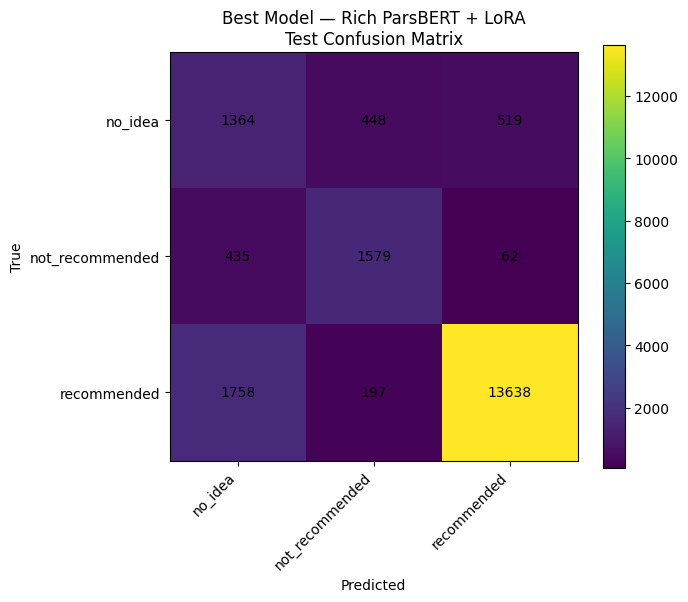

Saved:
/content/drive/MyDrive/DigikalaProject/eval/fatemeh/recommendation_classifier_v2/best_model_lora_test_confusion_matrix.png
/content/drive/MyDrive/DigikalaProject/eval/fatemeh/recommendation_classifier_v2/best_model_lora_test_classification_report.csv
/content/drive/MyDrive/DigikalaProject/eval/fatemeh/recommendation_classifier_v2/best_model_lora_test_predictions.csv


In [97]:
final_cm = confusion_matrix(
    y_test,
    lora_test_pred,
    labels=np.arange(len(LABELS)),
)

final_cm_df = pd.DataFrame(
    final_cm,
    index=[
        f"true_{label}"
        for label in LABELS
    ],
    columns=[
        f"pred_{label}"
        for label in LABELS
    ],
)

display(final_cm_df)


plt.figure(figsize=(7, 6))

plt.imshow(
    final_cm,
    interpolation="nearest",
)

plt.xticks(
    range(len(LABELS)),
    LABELS,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(LABELS)),
    LABELS,
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title(
    "Best Model — Rich ParsBERT + LoRA\n"
    "Test Confusion Matrix"
)

plt.colorbar()

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        plt.text(
            j,
            i,
            str(final_cm[i, j]),
            ha="center",
            va="center",
        )

plt.tight_layout()

FINAL_CM_PATH = (
    EVAL_DIR
    / "best_model_lora_test_confusion_matrix.png"
)

plt.savefig(
    FINAL_CM_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()


final_cm_df.to_csv(
    EVAL_DIR
    / "best_model_lora_test_confusion_matrix.csv"
)


pd.DataFrame(
    classification_report(
        y_test,
        lora_test_pred,
        labels=np.arange(len(LABELS)),
        target_names=LABELS,
        output_dict=True,
        zero_division=0,
    )
).T.to_csv(
    EVAL_DIR
    / "best_model_lora_test_classification_report.csv"
)


final_predictions = test_df.copy()

final_predictions["true_label"] = (
    le.inverse_transform(y_test)
)

final_predictions["predicted_label"] = (
    le.inverse_transform(lora_test_pred)
)

final_predictions["correct"] = (
    final_predictions["true_label"]
    == final_predictions["predicted_label"]
)

final_predictions.to_csv(
    EVAL_DIR
    / "best_model_lora_test_predictions.csv",
    index=False,
)


print("Saved:")
print(FINAL_CM_PATH)
print(
    EVAL_DIR
    / "best_model_lora_test_classification_report.csv"
)
print(
    EVAL_DIR
    / "best_model_lora_test_predictions.csv"
)